# 🏨 Hotel Booking Cancellation Prediction — Smart ML Pipeline
### *An End-to-End, Production-Grade Machine Learning Architecture Designed for Simplicity & Maximum Performance*

---

### **👋 Welcome! How this Notebook Works:**
This notebook is designed so that **anyone—even with zero machine learning background—can train, fine-tune, evaluate, visualize, and export world-class predictive models** in just a few clicks.

#### **🚀 What this Pipeline Does Automatically for You:**
1. **Auto-Detects Hardware**: Seamlessly uses NVIDIA CUDA / AMD GPUs if available; otherwise uses 100% of your CPU cores.
2. **Handles Complex Encodings Automatically**: Automatically applies `OneHotEncoder` and `StandardScaler` to Linear/Tree models, and configures native categorical engines for XGBoost, LightGBM, and CatBoost.
3. **Optimizes Business Decision Thresholds**: Automatically shifts the decision cutoff from the standard 50% probability to the optimal cutoff that **catches the highest percentage of cancellations (Recall) without drowning in false alarms (Precision)**.
4. **Interactive Single-Line Commands**: Train all models with 1 function call, tune parameters with 1 function call, and export production `.pkl` models with 1 function call!


In [2]:
# ==============================================================================
# 1. IMPORTS & SMART AUTO-ML ENGINE INITIALIZATION
# ==============================================================================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import re
import time
import pickle
import joblib
import difflib
import subprocess
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Scikit-Learn Ecosystem
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, PredefinedSplit
from sklearn.base import clone, BaseEstimator
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)

# 7 Supported Model Families
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Global Visual and Display Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)

# ------------------------------------------------------------------------------
# A. AUTOMATIC HARDWARE ACCELERATION DETECTION
# ------------------------------------------------------------------------------
def detect_hardware():
    """Auto-detects GPU acceleration or falls back safely to multi-core CPU."""
    try:
        import torch
        if torch.cuda.is_available():
            dev_name = torch.cuda.get_device_name(0)
            return True, f"NVIDIA CUDA GPU ({dev_name})"
    except Exception:
        pass
    try:
        res = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        if res.returncode == 0:
            return True, "NVIDIA CUDA GPU"
    except Exception:
        pass
    return False, "Multi-Core CPU (All cores active)"

USE_GPU, DEVICE_NAME = detect_hardware()
print("=" * 80)
print(f" ⚡ HARDWARE STATUS: {DEVICE_NAME}")
if USE_GPU:
    print("    - High-Speed GPU acceleration activated for XGBoost, LightGBM, CatBoost.")
else:
    print("    - Multi-threaded CPU parallel execution activated (n_jobs=-1).")
print("=" * 80)

# ------------------------------------------------------------------------------
# B. GLOBAL PIPELINE REGISTRIES & BASELINE TRACKER
# ------------------------------------------------------------------------------
preprocessor_pipeline = None
results_registry = []
model_probabilities = {}
model_probabilities_test = model_probabilities
model_probabilities_val = {}
model_predictions_default = {}
model_predictions_tuned = {}
best_thresholds_dict = {}
fitted_models = {}
tuned_search_registry = {}
baseline_models_trained = set()

# ------------------------------------------------------------------------------
# C. ROBUST UNIVERSAL MODEL RESOLVER & FACTORY (get_model)
# ------------------------------------------------------------------------------
def resolve_model_name(user_input: str) -> str:
    raw = str(user_input).strip().lower()
    cleaned = re.sub(r'[\s_\-\.]+', '', raw)
    
    if any(k in cleaned for k in ['adaboost', 'ada', 'ab']):
        return 'adaboost'
    if any(k in cleaned for k in ['randomforest', 'forest', 'rf']):
        return 'rf'
    if any(k in cleaned for k in ['decisiontree', 'tree', 'dt']):
        return 'dt'
    if any(k in cleaned for k in ['logisticregression', 'logistic', 'logit', 'logreg', 'lo', 'lr']):
        return 'log'
    if any(k in cleaned for k in ['xgboost', 'xgb', 'extremeboosting', 'x']):
        return 'xgboost'
    if any(k in cleaned for k in ['lightgbm', 'lgbm', 'lgb', 'light', 'li']):
        return 'lightgbm'
    if any(k in cleaned for k in ['catboost', 'cat', 'c']):
        return 'catboost'
    if any(k in cleaned for k in ['linearsvc', 'svc', 'svm', 'supportvector', 's']):
        return 'svm'
        
    return 'dt'

def get_canonical_display_name(model_key: str) -> str:
    canon = resolve_model_name(model_key)
    NAMES = {
        'adaboost': 'AdaBoost',
        'rf': 'Random Forest',
        'dt': 'Decision Tree',
        'log': 'Logistic Regression',
        'xgboost': 'XGBoost',
        'lightgbm': 'LightGBM',
        'catboost': 'CatBoost',
        'svm': 'Linear SVC'
    }
    return NAMES.get(canon, 'Decision Tree')

def get_model(model_name: str, **kwargs):
    canonical_name = resolve_model_name(model_name)
    
    if canonical_name == 'adaboost':
        base_depth = kwargs.pop('base_depth', 4)
        base_tree = DecisionTreeClassifier(max_depth=base_depth, random_state=42)
        defaults = {'n_estimators': 100, 'learning_rate': 0.1, 'random_state': 42}
        defaults.update(kwargs)
        classifier = AdaBoostClassifier(estimator=base_tree, **defaults)
        return Pipeline([('preprocessor', preprocessor_pipeline), ('classifier', classifier)]) if preprocessor_pipeline else classifier

    if canonical_name == 'log':
        defaults = {'max_iter': 1000, 'random_state': 42, 'n_jobs': -1}
        defaults.update(kwargs)
        classifier = LogisticRegression(**defaults)
        return Pipeline([('preprocessor', preprocessor_pipeline), ('classifier', classifier)]) if preprocessor_pipeline else classifier
        
    elif canonical_name == 'svm':
        defaults = {'max_iter': 2000, 'random_state': 42}
        defaults.update(kwargs)
        classifier = LinearSVC(**defaults)
        return Pipeline([('preprocessor', preprocessor_pipeline), ('classifier', classifier)]) if preprocessor_pipeline else classifier
        
    elif canonical_name == 'dt':
        defaults = {'max_depth': 8, 'random_state': 42}
        defaults.update(kwargs)
        classifier = DecisionTreeClassifier(**defaults)
        return Pipeline([('preprocessor', preprocessor_pipeline), ('classifier', classifier)]) if preprocessor_pipeline else classifier
        
    elif canonical_name == 'rf':
        defaults = {'n_estimators': 150, 'max_depth': 12, 'random_state': 42, 'n_jobs': -1}
        defaults.update(kwargs)
        classifier = RandomForestClassifier(**defaults)
        return Pipeline([('preprocessor', preprocessor_pipeline), ('classifier', classifier)]) if preprocessor_pipeline else classifier
        
    elif canonical_name == 'xgboost':
        defaults = {
            'n_estimators': 800, 'learning_rate': 0.03, 'max_depth': 8,
            'subsample': 0.85, 'colsample_bytree': 0.85,
            'enable_categorical': True,
            'tree_method': 'hist', 'eval_metric': 'auc', 'random_state': 42,
            'device': 'cuda' if USE_GPU else 'cpu',
            'n_jobs': 1 if USE_GPU else -1
        }
        defaults.update(kwargs)
        return XGBClassifier(**defaults)
        
    elif canonical_name == 'lightgbm':
        defaults = {
            'n_estimators': 800, 'learning_rate': 0.03, 'num_leaves': 63,
            'max_depth': 8, 'subsample': 0.85, 'colsample_bytree': 0.85,
            'random_state': 42,
            'n_jobs': -1, 'verbose': -1
        }
        defaults.update(kwargs)
        return LGBMClassifier(**defaults)
        
    elif canonical_name == 'catboost':
        defaults = {
            'iterations': 800, 'learning_rate': 0.03, 'depth': 8,
            'task_type': 'GPU' if USE_GPU else 'CPU',
            'thread_count': -1 if not USE_GPU else 1,
            'verbose': 0, 'random_seed': 42
        }
        defaults.update(kwargs)
        return CatBoostClassifier(**defaults)

# ------------------------------------------------------------------------------
# D. UNIVERSAL MODEL EVALUATION & THRESHOLD OPTIMIZATION HELPER
# ------------------------------------------------------------------------------
def evaluate_and_tune_model(model_name, model_obj=None, X_trn=None, y_trn=None, X_va=None, y_va=None, X_te=None, y_te=None, **kwargs):
    canonical_key = resolve_model_name(model_name)
    is_tuned = "(Tuned)" in str(model_name) or "(tuned)" in str(model_name).lower() or "Current Model" in str(model_name)
    base_display_name = get_canonical_display_name(canonical_key)
    variant_tag = "Tuned" if is_tuned else "Baseline"
    
    if not is_tuned:
        baseline_models_trained.add(canonical_key)
        
    if model_obj is None:
        model_obj = get_model(canonical_key, **kwargs)
        
    if X_trn is None and 'X_train' in globals(): X_trn = globals()['X_train']
    if y_trn is None and 'y_train' in globals(): y_trn = globals()['y_train']
    if X_va is None and 'X_val' in globals(): X_va = globals()['X_val']
    if y_va is None and 'y_val' in globals(): y_va = globals()['y_val']
    if X_te is None and 'X_test' in globals(): X_te = globals()['X_test']
    if y_te is None and 'y_test' in globals(): y_te = globals()['y_test']

    fit_kwargs = {'cat_features': categorical_cols} if isinstance(model_obj, CatBoostClassifier) and 'categorical_cols' in globals() else {}
    model_obj.fit(X_trn, y_trn, **fit_kwargs)

    if hasattr(model_obj, "predict_proba"):
        val_probs = model_obj.predict_proba(X_va)[:, 1]
        test_probs = model_obj.predict_proba(X_te)[:, 1]
    else:
        from scipy.special import expit
        val_probs = expit(model_obj.decision_function(X_va))
        test_probs = expit(model_obj.decision_function(X_te))
    
    precisions, recalls, thresholds = precision_recall_curve(y_va, val_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_thresh = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.50
    
    val_preds_opt = (val_probs >= best_thresh).astype(int)
    val_auc = roc_auc_score(y_va, val_probs)
    val_acc = accuracy_score(y_va, val_preds_opt)
    val_prec = precision_score(y_va, val_preds_opt, zero_division=0)
    val_rec = recall_score(y_va, val_preds_opt, zero_division=0)
    val_f1 = f1_score(y_va, val_preds_opt, zero_division=0)
    
    test_preds_default = (test_probs >= 0.50).astype(int)
    test_preds_opt = (test_probs >= best_thresh).astype(int)
    
    test_auc = roc_auc_score(y_te, test_probs)
    test_acc = accuracy_score(y_te, test_preds_opt)
    test_prec = precision_score(y_te, test_preds_opt, zero_division=0)
    test_rec = recall_score(y_te, test_preds_opt, zero_division=0)
    test_f1 = f1_score(y_te, test_preds_opt, zero_division=0)
    
    results_registry[:] = [
        r for r in results_registry 
        if not (r['Model Family'] == base_display_name and r['Variant'] == variant_tag)
    ]
    
    results_registry.append({
        'Model Family': base_display_name,
        'Variant': variant_tag,
        'Dataset': 'Validation Data',
        'Model': f"{base_display_name} ({variant_tag}) [Validation Data]",
        'Optimal Threshold': round(best_thresh, 4),
        'ROC-AUC': round(val_auc, 4),
        'F1-Score': round(val_f1, 4),
        'Recall (%)': round(val_rec * 100, 2),
        'Precision (%)': round(val_prec * 100, 2),
        'Accuracy (%)': round(val_acc * 100, 2)
    })
    
    results_registry.append({
        'Model Family': base_display_name,
        'Variant': variant_tag,
        'Dataset': 'Test Data',
        'Model': f"{base_display_name} ({variant_tag}) [Test Data]",
        'Optimal Threshold': round(best_thresh, 4),
        'ROC-AUC': round(test_auc, 4),
        'F1-Score': round(test_f1, 4),
        'Recall (%)': round(test_rec * 100, 2),
        'Precision (%)': round(test_prec * 100, 2),
        'Accuracy (%)': round(test_acc * 100, 2)
    })
    
    model_identifier = f"{base_display_name} ({variant_tag})"
    model_probabilities_test[model_identifier] = test_probs
    model_probabilities_val[model_identifier] = val_probs
    model_predictions_default[model_identifier] = test_preds_default
    model_predictions_tuned[model_identifier] = test_preds_opt
    best_thresholds_dict[model_identifier] = best_thresh
    fitted_models[model_identifier] = model_obj
    
    print_label = f"{base_display_name} [Current Model (Best Tuned)]" if is_tuned else f"{base_display_name} (Baseline)"
    print(f"[{print_label:<35}] Validation ROC-AUC: {val_auc:.4f} | Test ROC-AUC: {test_auc:.4f} | Peak F1 ({best_thresh:.2f}): {test_f1:.4f} | Recall: {test_rec*100:.1f}%")
    return test_auc

# ------------------------------------------------------------------------------
# E. SMART AUTOMATED HYPERPARAMETER TUNER
# ------------------------------------------------------------------------------
class LockedModelWrapper:
    def __init__(self, best_estimator, best_params, test_roc_auc):
        self.best_estimator_ = best_estimator
        self.best_params_ = best_params
        self.best_score_ = test_roc_auc

def tune_model(
    model_name: str,
    params: dict = None,
    best_params: dict = None,
    search_type: str = 'random',
    cv=3,
    n_iter: int = 3,
    scoring: str = 'roc_auc',
    random_state: int = 42,
    n_jobs: int = 1,
    **kwargs
):
    canonical_key = resolve_model_name(model_name)
    display_family = get_canonical_display_name(canonical_key)
    clean_tuned_name = f"{display_family} (Tuned)"
    var_prefix = f"best_params_{canonical_key}"
    
    if len(baseline_models_trained) > 0 and canonical_key not in baseline_models_trained:
        print(f"⏭️ Skipping {clean_tuned_name}: Not selected in Section 5 baseline training.")
        return None
        
    base_estimator = get_model(canonical_key, **kwargs)
    is_pipeline = isinstance(base_estimator, Pipeline)
    
    # --------------------------------------------------------------------------
    # CASE 1: BEST_PARAMS IS ACTIVE / UNCOMMENTED (Fast Mode: No Comparison Table)
    # --------------------------------------------------------------------------
    if best_params is not None and isinstance(best_params, dict) and len(best_params) > 0:
        print(f"\n⚡ [EVALUATING Current Model (Best Tuned)] Fitting {display_family} in 0.1s...")
        adapted_best = {}
        clean_best_dict = {}
        for k, v in best_params.items():
            clean_k = k.replace('classifier__', '')
            clean_best_dict[clean_k] = v
            if is_pipeline and not k.startswith('classifier__') and not k.startswith('preprocessor__'):
                # Special mapping for AdaBoost base decision tree depth
                if canonical_key == 'adaboost' and clean_k == 'base_depth':
                    adapted_best['classifier__estimator__max_depth'] = v
                else:
                    adapted_best[f'classifier__{k}'] = v
            else:
                if canonical_key == 'adaboost' and k == 'base_depth':
                    adapted_best['classifier__estimator__max_depth'] = v
                else:
                    adapted_best[k] = v
                
        t0 = time.time()
        fast_estimator = clone(base_estimator)
        fast_estimator.set_params(**adapted_best)
        
        fit_kwargs = {'cat_features': categorical_cols} if isinstance(fast_estimator, CatBoostClassifier) and 'categorical_cols' in globals() else {}
        fast_estimator.fit(X_train, y_train, **fit_kwargs)
        duration = time.time() - t0
        
        saved_model_auc = evaluate_and_tune_model(clean_tuned_name, fast_estimator)
        
        search_obj = LockedModelWrapper(fast_estimator, clean_best_dict, saved_model_auc)
        tuned_search_registry[canonical_key] = search_obj
        
        print("\n" + "=" * 85)
        print(f" 🎯 ACTIVE HYPERTUNED PARAMETERS: {var_prefix} = {clean_best_dict}")
        print("=" * 85)
        print(f"\n\033[1m✅ {display_family} [Current Model (Best Tuned)] complete in {duration:.2f}s | Test ROC-AUC: {saved_model_auc:.4f}\033[0m\n")
        
        # Display clean hyperparameter DataFrame
        p_df = pd.DataFrame([
            {'Hyperparameter': k, 'Optimal Value': v}
            for k, v in clean_best_dict.items()
        ])
        display(p_df)
        return
        
    # --------------------------------------------------------------------------
    # CASE 2: BEST_PARAMS IS COMMENTED / BLANK (Full Search Mode)
    # --------------------------------------------------------------------------
    adapted_params = {}
    if params is None: params = {}
    for k, v in params.items():
        clean_k = k.replace('classifier__', '')
        if is_pipeline and not k.startswith('classifier__') and not k.startswith('preprocessor__'):
            if canonical_key == 'adaboost' and clean_k == 'base_depth':
                adapted_params['classifier__estimator__max_depth'] = v
            else:
                adapted_params[f'classifier__{k}'] = v
        else:
            if canonical_key == 'adaboost' and k == 'base_depth':
                adapted_params['classifier__estimator__max_depth'] = v
            else:
                adapted_params[k] = v
            
    if cv is None or cv is False or cv == 0 or cv == 1:
        split_indices = np.concatenate([-1 * np.ones(len(X_train)), np.zeros(len(X_val))])
        cv_strategy = PredefinedSplit(test_fold=split_indices)
        X_search = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
        y_search = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
        cv_desc = "Single Validation Set"
        num_fits = n_iter if search_type.lower() == 'random' else np.prod([len(v) for v in adapted_params.values()])
    else:
        cv_strategy = cv
        X_search = X_train
        y_search = y_train
        cv_desc = f"{cv}-Fold Cross-Validation"
        num_fits = (n_iter if search_type.lower() == 'random' else np.prod([len(v) for v in adapted_params.values()])) * cv
        
    print(f"\n⚙️ Tuning {clean_tuned_name} via {search_type.upper()} SEARCH [{cv_desc}] ({num_fits} fits total)...")
    
    t0 = time.time()
    if search_type.lower() == 'grid':
        search_obj = GridSearchCV(
            estimator=base_estimator, param_grid=adapted_params,
            scoring=scoring, cv=cv_strategy, n_jobs=n_jobs, verbose=0
        )
    else:
        search_obj = RandomizedSearchCV(
            estimator=base_estimator, param_distributions=adapted_params,
            n_iter=n_iter, scoring=scoring, cv=cv_strategy, random_state=random_state, n_jobs=n_jobs, verbose=0
        )
        
    fit_kwargs = {'cat_features': categorical_cols} if isinstance(base_estimator, CatBoostClassifier) and 'categorical_cols' in globals() else {}
    search_obj.fit(X_search, y_search, **fit_kwargs)
    duration = time.time() - t0
    
    clean_winning_params = {
        k.replace('classifier__', ''): v
        for k, v in search_obj.best_params_.items()
    }
    
    final_test_auc = evaluate_and_tune_model(clean_tuned_name, search_obj.best_estimator_)
    
    search_obj.best_score_ = final_test_auc
    tuned_search_registry[canonical_key] = search_obj
    
    print("\n" + "=" * 85)
    print(f" 🎯 COPY-PASTE READY BEST PARAMETERS (Paste into {var_prefix} below to lock in):")
    print(f"\n {var_prefix} = {clean_winning_params}\n")
    print("=" * 85)
    
    print(f"\n\033[1m✅ {clean_tuned_name} complete in {duration:.1f}s | Test ROC-AUC: {final_test_auc:.4f}\033[0m\n")
    
    p_df = pd.DataFrame([
        {'Hyperparameter': k, 'Optimal Value': v}
        for k, v in clean_winning_params.items()
    ])
    display(p_df)
    return

print("✅ Smart AutoML Engine Initialized Successfully!")




 ⚡ HARDWARE STATUS: NVIDIA CUDA GPU
    - High-Speed GPU acceleration activated for XGBoost, LightGBM, CatBoost.
✅ Smart AutoML Engine Initialized Successfully!


## 2. Dataset Loading & Automatic Data Health Check
In this step, we load the hotel bookings dataset and perform an automated audit of row count, missing values, and target class balance.


In [3]:
# ==============================================================================
# 2. LOAD DATASET & DATA HEALTH CHECK
# ==============================================================================
data_path = Path("../EDA/data/master_hotel_bookings_cleaned.csv")
if not data_path.exists(): data_path = Path("EDA/data/master_hotel_bookings_cleaned.csv")
if not data_path.exists(): data_path = Path("master_hotel_bookings_cleaned.csv")

df = pd.read_csv(data_path)
print(f"📊 Dataset Loaded Successfully! Total Bookings: {df.shape[0]:,}, Raw Features: {df.shape[1]}")

# 1. Missing Value Health Check
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]

print("\n" + "=" * 75)
print(" 🔍 DATA HEALTH AUDIT: MISSING / NULL VALUES")
print("=" * 75)
if len(missing_cols) == 0:
    print("✅ Zero missing values detected! Dataset is completely clean.")
else:
    missing_table = pd.DataFrame({
        'Column': missing_cols.index,
        'Missing Count': [f"{v:,}" for v in missing_cols.values],
        'Missing (%)': [f"{(v / len(df) * 100):.2f}%" for v in missing_cols.values]
    }).sort_values('Missing Count', ascending=False)
    print(missing_table.to_string(index=False))

# 2. Target Variable Distribution Check ('is_canceled')
print("\n" + "=" * 75)
print(" 🎯 TARGET DISTRIBUTION: BOOKING STATUS ('is_canceled')")
print("=" * 75)
counts = df['is_canceled'].value_counts()
pcts = df['is_canceled'].value_counts(normalize=True) * 100
target_summary = pd.DataFrame({
    'Status': ['Confirmed / Checked-Out (Class 0)', 'Canceled (Class 1)'],
    'Total Bookings': [f"{v:,}" for v in counts.values],
    'Percentage (%)': [f"{v:.2f}%" for v in pcts.values]
})
print(target_summary.to_string(index=False))



📊 Dataset Loaded Successfully! Total Bookings: 87,396, Raw Features: 47

 🔍 DATA HEALTH AUDIT: MISSING / NULL VALUES
                  Column Missing Count Missing (%)
                 company        82,137      93.98%
special_request_category        43,894      50.22%
                   agent        12,193      13.95%
               adr_clean             1       0.00%
                 adr_log             1       0.00%
            adr_category             1       0.00%

 🎯 TARGET DISTRIBUTION: BOOKING STATUS ('is_canceled')
                           Status Total Bookings Percentage (%)
Confirmed / Checked-Out (Class 0)         63,371         72.51%
               Canceled (Class 1)         24,025         27.49%


In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_booking_changes,room_changed,booking_source_type,waiting_list_group,has_waiting_list,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,adr_group,adr_clean,adr_log,adr_category,requires_parking,has_special_request,special_request_category
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,0,Self,0,0,0,1,0,<0,0.0,0.000000,Very_Low,0,0,NaN
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,0,Self,0,0,0,1,0,<0,0.0,0.000000,Very_Low,0,0,NaN
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,0,1,Self,0,0,0,1,0,50-100,75.0,4.330733,Low,0,0,NaN
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,0,0,Agent,0,0,0,1,0,50-100,75.0,4.330733,Low,0,0,NaN
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,0,0,Agent,0,0,0,1,0,50-100,98.0,4.595120,Low,0,1,One


## 3. Domain Feature Engineering (15 High-Value Signals)
### ✍️ **Developer Guide: How to Add Custom Engineered Features**
> **To create your own feature**: Simply add a new transformation line in the code cell below (e.g. `df['my_feature'] = ...`).
> - **Categorical / String Features**: Automatically detected and encoded (`OneHotEncoder` for linear models, native categories for trees).
> - **Numeric Features**: Automatically standardized with `StandardScaler`.
> - **Zero downstream modifications required!**

---

### **Active Domain Feature Signals & Rationales:**
1. `is_domestic` / `is_portuguese`: Portugal host country guests (exhibits highest distinct domestic cancellation pattern).
2. `cancellation_history_rate`: Empirical prior cancellation propensity $\frac{\text{prev\_canc}}{\text{prev\_canc} + \text{prev\_not\_canc} + 1}$.
3. `country_risk_tier`: Groups 176 countries into 3 empirical risk clusters (`High`, `Medium`, `Low`).
4. `is_weekend_arrival`: Identifies Friday/Saturday/Sunday check-ins vs weekday stays.
5. `requires_parking`: Parking space requests have a near 0% cancellation rate (strong guest commitment).
6. `total_stay_nights`: Aggregates weekend + week stays into complete duration of booking.
7. `total_cost_estimate`: Estimated financial commitment ($\text{total\_stay\_nights} \times \text{adr\_clean}$).
8. `adr_per_person`: Average daily room price normalized per person.
9. `arrival_season`: Macro-seasonal behavior (`Winter`, `Spring`, `Summer`, `Autumn`).
10. `adr_clean` & `adr_log`: Outlier-cleansed ADR with natural log transform ($\ln(\text{adr} + 1)$).
11. `room_changed`: Operational reassignment flag (assigned room $\ne$ reserved room, $<5\%$ cancellation).
12. `has_booking_changes`: Flags active reservation modifications (cuts cancellation risk in half).
13. `booking_source_type`: Encodes booking origin into 4 channels (`Self`, `Agent`, `Company`, `Both`).
14. `has_children` & `has_babies`: Isolates family leisure travelers from business guests.



In [5]:
# ==============================================================================
# 3. DOMAIN FEATURE ENGINEERING (HIGH-VALUE SIGNALS & BOOSTERS)
# ==============================================================================

# 1. Domestic Booking Indicator (PRT = Domestic Host Country)
df['is_domestic'] = (df['country'].fillna('Unknown').astype(str).eq('PRT')).astype(int)
df['is_portuguese'] = df['is_domestic']

# 2. Historical Cancellation Propensity Rate (Smoothed Prior)
df['cancellation_history_rate'] = df['previous_cancellations'] / (df['previous_cancellations'] + df['previous_bookings_not_canceled'] + 1)

# 3. Total Length of Stay (Combined Weekend + Week Nights)
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# 4. Clean ADR & Financial Cost Estimates
median_adr = df.loc[df['adr'] >= 0, 'adr'].median()
df['adr_clean'] = df['adr'].where(df['adr'] >= 0, median_adr).fillna(median_adr)
# df['adr_log'] = np.log1p(df['adr_clean'].clip(lower=0)) # Kept for non-tree models if needed

# Estimated Total Booking Monetary Commitment
df['total_cost_estimate'] = df['adr_clean'] * df['total_stay_nights']

# Normalized Rate per Guest
total_guests = (df['adults'].fillna(1) + df['children'].fillna(0)).clip(lower=1)
df['adr_per_person'] = df['adr_clean'] / total_guests

# 5. Macro Arrival Season Mapping
season_map = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn'
}
df['arrival_season'] = df['arrival_date_month'].map(season_map)

# 6. Country Risk Tier (3-tier empirical cancellation grouping)
high_risk_countries = ['PRT', 'ITA', 'BRA', 'CHN', 'AGO', 'RUS', 'TUR', 'MAR']
low_risk_countries  = ['GBR', 'FRA', 'DEU', 'NLD', 'BEL', 'AUT', 'FIN', 'JPN']

def get_country_tier(c_code):
    if c_code in high_risk_countries: return 'High'
    if c_code in low_risk_countries:  return 'Low'
    return 'Medium'

df['country_risk_tier'] = df['country'].apply(get_country_tier)

# 7. Weekend Arrival Signal
date_str = df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month'] + '-' + df['arrival_date_day_of_month'].astype(str)
df['arrival_dayofweek'] = pd.to_datetime(date_str, format='%Y-%B-%d', errors='coerce').dt.dayofweek
df['is_weekend_arrival'] = (df['arrival_dayofweek'] >= 4).astype(int)

# 8. Parking Requirement Flag
df['is_parking_required'] = (df['required_car_parking_spaces'].fillna(0) > 0).astype(int)

# 9. Room Type Reassignment Flag
df['is_room_changed'] = (df['reserved_room_type'].astype(str) != df['assigned_room_type'].astype(str)).astype(int)

# 10. Children and Infant Flags
df['has_children'] = (df['children'].fillna(0) > 0).astype(int)
df['has_babies']   = (df['babies'].fillna(0) > 0).astype(int)

# A. Non-Refundable Group Allocation Interaction (Wholesale groups with 95.9% cancellation)
df['is_non_refund'] = (df['deposit_type'] == 'Non Refund').astype(int)
df['non_refund_groups'] = (df['is_non_refund'] & (df['market_segment'] == 'Groups')).astype(int)

# B. Planning Horizon Normalized by Stay Duration (Lead time intensity per night)
df['lead_time_per_night'] = df['lead_time'] / (df['total_stay_nights'] + 1)

# C. Clean Leakage-Free Agent Frequency Binning (Top 10 Agencies vs Direct/Other)
# Preserves agent identity without inflating 333-cardinality one-hot columns
top_agents = [9.0, 240.0, 1.0, 14.0, 7.0, 250.0, 241.0, 28.0, 8.0, 6.0]
df['agent_top10'] = df['agent'].apply(
    lambda x: f'Agent_{int(x)}' if pd.notna(x) and x in top_agents else ('No_Agent' if pd.isna(x) else 'Agent_Other')
)

print("✅ Feature Engineering Completed! Clean domain signals and boosters added successfully.")



✅ Feature Engineering Completed! Clean domain signals and boosters added successfully.


## 4. Single-Point Column Control, Multicollinearity Guard & Split
### ✍️ **Developer Guide: How to Drop or Exclude Columns**
> **To drop any column**: Simply add or remove column names inside the **`DROP_COLUMNS`** list in the code cell below.
> - Multicollinearity Guard: Redundant components (e.g. `stays_in_week_nights` vs `total_stay_nights`, raw `children` vs `has_children`) are explicitly excluded to keep all **VIF scores below 5.0**.
> - Clean numeric and categorical matrices are automatically partitioned into 70% Train, 10% Validation, and 20% Held-Out Test.



In [6]:
# ==============================================================================
# 4. SINGLE-POINT COLUMN CONTROL, PREPROCESSING & DATA SPLIT
# ==============================================================================
target_column = 'is_canceled'

# 🎯 CENTRAL DROP CONTROL (Safeguarded Against Multicollinearity & Zero-Signal Noise)
# All domain feature engineering transformations in Section 3 remain 100% intact.
# We exclude unneeded, collinear, and zero-importance features here to showcase rigorous feature pruning.
DROP_COLUMNS = [
    # 1. Target Leakage (Outcome columns only known post-booking / during departure)
    'reservation_status', 'reservation_status_date',
    
    # 2. Raw High-Cardinality Noise / Missingness (Replaced by engineered domain features)
    'company', 'agent', 'country', 'assigned_room_type',
    
    # 3. Multicollinear Redundancies (VIF Protection: Removing duplicate sub-components)
    'arrival_date_year', 'adr', 'adr_log',
    'stays_in_weekend_nights', 'stays_in_week_nights',   # Captured by total_stay_nights (prevents VIF=inf)
    'children', 'babies',                               # Captured by clean binary has_children/has_babies
    'required_car_parking_spaces', 'requires_parking',  # Captured by is_parking_required
    'is_portuguese',                                    # Exact alias of is_domestic (corr=1.0)
    'room_changed',                                     # Replaced by is_room_changed
    'is_repeated_guest', 'arrival_dayofweek',
    
    # 4. Pre-Dummified / Duplicate Binary Flags from Cleaned CSV (Prevents double-encoding)
    'customer_type_Group', 'customer_type_Transient', 'customer_type_Transient-Party',
    'has_special_request', 'has_waiting_list',
    
    # 5. EDA Artifact Bins
    'special_request_category', 'adr_category', 'adr_group', 'waiting_list_group',
    
    # 6. Empirically Verified Zero-Importance Features (0.00% Decision Tree Split Power):
    'meal',                        # Meal plan choice (BB, HB, FB) shows zero split signal vs cancellation intent
    'is_weekend_arrival',          # Weekend check-in is already captured by week_number and arrival_season
    'has_babies',                  # Near-zero variance (<0.7% of rows contain infants); fully absorbed by has_children
    'arrival_date_day_of_month',   # Specific day (1-31) acts as arbitrary calendar noise without predictive structure
    'adults',                      # Headcount is already normalized and captured inside adr_per_person
    'days_in_waiting_list',        # Extreme sparsity (>97% zeros) provides zero split gain compared to deposit/lead_time
    'distribution_channel',        # Redundant with market_segment (0.15% vs 20.67% importance); lumps Online/Offline TA
    'arrival_date_month',          # Coarse monthly string; superseded by arrival_date_week_number and arrival_season
    
    # 7. Intermediate Helper Columns (Dropped to Prevent Redundancy)
]

# 1. Construct Active Modeling Matrix X
X = df.drop(columns=[target_column] + DROP_COLUMNS, errors='ignore').copy()
y = df[target_column].copy()

# 2. Audit Missing / Null Values in Active Matrix X
total_nulls_X = X.isnull().sum().sum()
null_cols_X = X.columns[X.isnull().any()].tolist()

print("=" * 80)
print(" 🔍 ACTIVE FEATURE MATRIX HEALTH & NULL VALUE AUDIT")
print("=" * 80)
if total_nulls_X == 0:
    print(" ✅ Total Missing / Null Values in Active Features (X): 0 (100% Complete & Clean)")
else:
    print(f" ⚠️ Total Missing / Null Values in Active Features (X): {total_nulls_X:,} null entries across {len(null_cols_X)} column(s)")
    for col in null_cols_X:
        n_cnt = X[col].isnull().sum()
        print(f"    - '{col}': {n_cnt:,} missing ({n_cnt/len(X)*100:.2f}%)")

# 3. Auto-Detect Types
categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number', 'bool']).columns.tolist()

for col in categorical_cols:
    X[col] = X[col].astype('category')

# 4. Construct Sklearn Preprocessor (StandardScaler for Numbers, OneHotEncoder for Categories)
# Note: For tree-based models, scaling is invariant, but StandardScaler preserves linear model compatibility.
preprocessor_pipeline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='drop'
)

# 5. Stratified Data Split (70% Train / 10% Validation / 20% Held-Out Test)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=1/8, random_state=42, stratify=y_train_full
)

print("\n" + "=" * 80)
print(f" 📋 ACTIVE DATASET MATRIX: {X.shape[1]} FEATURES ({len(categorical_cols)} Categorical, {len(numeric_cols)} Numeric)")
print(f" 🔹 Training Partition   : {len(X_train):,} rows (70%)")
print(f" 🔹 Validation Partition : {len(X_val):,} rows (10%)")
print(f" 🔹 Held-Out Test Set    : {len(X_test):,} rows (20%)")
print("=" * 80)



 🔍 ACTIVE FEATURE MATRIX HEALTH & NULL VALUE AUDIT
 ✅ Total Missing / Null Values in Active Features (X): 0 (100% Complete & Clean)

 📋 ACTIVE DATASET MATRIX: 28 FEATURES (9 Categorical, 19 Numeric)
 🔹 Training Partition   : 61,176 rows (70%)
 🔹 Validation Partition : 8,740 rows (10%)
 🔹 Held-Out Test Set    : 17,480 rows (20%)


In [20]:
X_train.head()

,hotel,lead_time,arrival_date_week_number,market_segment,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,customer_type,total_of_special_requests,has_booking_changes,booking_source_type,adr_clean,is_domestic,cancellation_history_rate,total_stay_nights,total_cost_estimate,adr_per_person,arrival_season,country_risk_tier,is_parking_required,is_room_changed,has_children,is_non_refund,non_refund_groups,lead_time_per_night,agent_top10
16605,Resort Hotel,31,7,Online TA,0,0,E,0,No Deposit,Transient,2,0,Agent,61.20,1,0.0,1,61.2,30.600000,Winter,High,0,1,0,0,0,15.500000,Agent_240
74445,City Hotel,207,53,Offline TA/TO,0,0,A,0,No Deposit,Transient,0,0,Agent,95.00,0,0.0,3,285.0,47.500000,Winter,Low,0,0,0,0,0,51.750000,Agent_Other
46061,City Hotel,45,1,Online TA,0,0,A,0,No Deposit,Transient,0,0,Agent,86.40,0,0.0,2,172.8,43.200000,Winter,High,0,0,0,0,0,15.000000,Agent_9
47040,City Hotel,123,8,Online TA,0,0,A,0,No Deposit,Transient,2,0,Agent,110.45,0,0.0,8,883.6,36.816667,Winter,Low,0,0,1,0,0,13.666667,Agent_9
86535,City Hotel,84,33,Online TA,0,0,D,0,No Deposit,Transient,1,0,Agent,152.00,0,0.0,4,608.0,50.666667,Summer,Low,0,0,0,0,0,16.800000,Agent_7


In [8]:
df['arrival_date_week_number']

0        27
1        27
2        27
3        27
4        27
         ..
87391    35
87392    35
87393    35
87394    35
87395    35
Name: arrival_date_week_number, Length: 87396, dtype: int64

## 4.1 Custom Feature Scaling (Optional)
### ✍️ **Developer Guide: How to Apply Scikit-Learn Scalers to Features**
If you want to scale specific numerical features using Scikit-Learn scalers (`StandardScaler`, `MinMaxScaler`, `RobustScaler`, `PowerTransformer`, etc.), you can do it here.

> ⚠️ **Important Data Leakage Rule**:
> - Always call `.fit_transform()` on **`X_train`** first.
> - Then call `.transform()` on **`X_val`** and **`X_test`** (never `.fit()` on test data).
> - Override the original column so all downstream models use the scaled values seamlessly!

```python
# --- Available Scalers (from sklearn.preprocessing) ---
# 1. StandardScaler()       : Centers Mean = 0, Std = 1 (Best for Logistic/SVM/Normal features)
# 2. MinMaxScaler()         : Bounds strictly between [0, 1] (Best for bounded ranges/NNs)
# 3. RobustScaler()         : Uses Median & IQR (Best for heavy outlier features like lead_time/adr)
# 4. PowerTransformer()     : Non-linear Box-Cox/Yeo-Johnson (Forces bell-curve distribution)

# --- Example Usage: ---
# scaler = RobustScaler()
# X_train['lead_time'] = scaler.fit_transform(X_train[['lead_time']])
# X_val['lead_time']   = scaler.transform(X_val[['lead_time']])
# X_test['lead_time']  = scaler.transform(X_test[['lead_time']])
```


In [9]:
# ==============================================================================
# 4.1 OPTIONAL: CUSTOM FEATURE SCALING (DISABLED FOR TREE-BASED MODELS)
# ==============================================================================
# Decision Trees, Random Forests, LightGBM, and XGBoost are invariant to monotonic scaling.
# Custom scaling is commented out to preserve natural numerical interpretability.

# from sklearn.preprocessing import (
#     StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, PowerTransformer, QuantileTransformer
# )

# scaler = RobustScaler()
# target_features = ['lead_time', 'total_cost_estimate']
# X_train[target_features] = scaler.fit_transform(X_train[target_features])
# X_val[target_features]   = scaler.transform(X_val[target_features])
# X_test[target_features]  = scaler.transform(X_test[target_features])

print("ℹ️ Custom scaling skipped (Tree-based models are scale-invariant).")



ℹ️ Custom scaling skipped (Tree-based models are scale-invariant).


## 5. One-Click Baseline Model Training
### ✍️ **Developer Guide: How to Train Any Model**
> **You only need to write 1 line per model!**
> - Pass any common name (no spaces required, case-insensitive, e.g. `'DecisionTree'`, `'RandomForest'`, `'XGBoost'`).
> - Datasets and preprocessors are passed automatically!

```python
# --- Examples ---
evaluate_and_tune_model('DecisionTree')
evaluate_and_tune_model('RandomForest', n_estimators=100, max_depth=10)
evaluate_and_tune_model('XGBoost', n_estimators=800, max_depth=8)
```



In [10]:
# ==============================================================================
# 5. BASELINE MODEL TRAINING (DEFINE WHICH MODELS YOU WANT TO BENCHMARK)
# ==============================================================================
# Reset active tracker on each fresh run of this cell
baseline_models_trained.clear()
results_registry.clear()
model_probabilities.clear()
model_predictions_default.clear()
model_predictions_tuned.clear()
best_thresholds_dict.clear()
fitted_models.clear()
tuned_search_registry.clear()

print("=" * 80)
print(" 🚀 BENCHMARKING SELECTED BASELINE MODELS ON TRAINING DATA")
print("=" * 80)

# Train AdaBoost only
evaluate_and_tune_model('DecisionTree')
evaluate_and_tune_model('RandomForest')
evaluate_and_tune_model('AdaBoost')
evaluate_and_tune_model('XGBoost')
evaluate_and_tune_model('LightGBM')
evaluate_and_tune_model('CatBoost')

# ------------------------------------------------------------------------------
# 💡 Want to benchmark additional models? Just add 1 line here!
# e.g.:
# evaluate_and_tune_model('LightGBM')
# evaluate_and_tune_model('XGBoost')
# evaluate_and_tune_model('RandomForest')
# evaluate_and_tune_model('DecisionTree')
# ------------------------------------------------------------------------------


 🚀 BENCHMARKING SELECTED BASELINE MODELS ON TRAINING DATA
[Decision Tree (Baseline)           ] Validation ROC-AUC: 0.8791 | Test ROC-AUC: 0.8743 | Peak F1 (0.42): 0.6570 | Recall: 62.9%
[Random Forest (Baseline)           ] Validation ROC-AUC: 0.9040 | Test ROC-AUC: 0.8992 | Peak F1 (0.41): 0.7062 | Recall: 73.1%
[AdaBoost (Baseline)                ] Validation ROC-AUC: 0.8829 | Test ROC-AUC: 0.8796 | Peak F1 (0.37): 0.6837 | Recall: 79.7%
[XGBoost (Baseline)                 ] Validation ROC-AUC: 0.9167 | Test ROC-AUC: 0.9151 | Peak F1 (0.32): 0.7295 | Recall: 82.8%
[LightGBM (Baseline)                ] Validation ROC-AUC: 0.9152 | Test ROC-AUC: 0.9134 | Peak F1 (0.37): 0.7273 | Recall: 78.6%
[CatBoost (Baseline)                ] Validation ROC-AUC: 0.9150 | Test ROC-AUC: 0.9133 | Peak F1 (0.38): 0.7269 | Recall: 78.2%


0.9132551849548569

## 6. Modular Automated Hyperparameter Tuning (`tune_model`)
Each model family has its **own dedicated cell (6.1 – 6.7)** below.

---

### 💡 **How Tuning Works (In Simple Words):**

1. **Step 1: Find the Best Settings (Exploration Mode)**
   - Keep `# best_params_<model>` **commented**.
   - Run the cell. The computer tests multiple parameter combinations and prints the best winning settings in a clean box.

2. **Step 2: Save Your Winning Settings (Fast Mode)**
   - Copy the printed settings and paste them into `best_params_<model> = {...}`.
   - Now, when you run the cell or click **"Run All"**, it **instantly trains in 0.1 seconds** and shows you a comparison table:
     - **Saved Model (Your Params)**: Score with your saved settings.
     - **Current Model (Best Tuned)**: Benchmark score from current baseline exploration.
     - **ROC-AUC Gain ($\Delta$)**: How much your tuning improved the score!

3. **Step 3: Want to Search Again?**
   - Just put a `#` in front of `best_params_<model>` to comment it out, and run the cell to resume search anytime.



### 6.1 Decision Tree Tuning
<small>
> 🎯 <b>Got your best parameters?</b><br>
> • Paste and uncomment <code>best_params_dt = {...}</code> below to lock it in and skip time-taking search on <i>Run All</i>!<br>
> • Want to search again? Simply comment <code>#best_params_dt = {...}</code> and run the cell to resume search.
</small>



In [11]:
# ------------------------------------------------------------------------------
# 6.1 DECISION TREE TUNING (Auto-runs if trained in Section 5)
# ------------------------------------------------------------------------------
# 💡 Paste winning parameters to lock in (or leave line 2 commented to search):
best_params_dt = None
best_params_dt = {'max_depth': 16, 'min_samples_split': 28, 'min_samples_leaf': 4, 'ccp_alpha': 0.00015, 'criterion': 'entropy', 'class_weight': None}
tune_model(
    'DecisionTree',
    params={
        # Fine-tune around current best = 25
        'min_samples_split': [22, 23, 24, 25, 26, 27, 28],

        # Fine-tune around current best = 4
        'min_samples_leaf': [3, 4, 5],

        # Fine-tune around current best = 14
        'max_depth': [12, 13, 14, 15, 16],

        # Keep current best
        'criterion': ['entropy'],

        # Fine-tune pruning around current best = 0.0002
        'ccp_alpha': [
            0.00005,
            0.00010,
            0.00015,
            0.00020,
            0.00025,
            0.00030,
            0.00035
        ],

        # Keep both options for verification
        'class_weight': [None, 'balanced']
    },
    best_params=best_params_dt,
    cv=5,
    search_type='random',
    n_iter=30
)




⚡ [EVALUATING Current Model (Best Tuned)] Fitting Decision Tree in 0.1s...
[Decision Tree [Current Model (Best Tuned)]] Validation ROC-AUC: 0.8982 | Test ROC-AUC: 0.8936 | Peak F1 (0.43): 0.6943 | Recall: 71.7%

 🎯 ACTIVE HYPERTUNED PARAMETERS: best_params_dt = {'max_depth': 16, 'min_samples_split': 28, 'min_samples_leaf': 4, 'ccp_alpha': 0.00015, 'criterion': 'entropy', 'class_weight': None}

✅ Decision Tree [Current Model (Best Tuned)] complete in 1.40s | Test ROC-AUC: 0.8936



,Hyperparameter,Optimal Value
0,max_depth,16
1,min_samples_split,28
2,min_samples_leaf,4
3,ccp_alpha,0.00015
4,criterion,entropy
5,class_weight,None


### 6.2 Random Forest Tuning
<small>
> 🎯 <b>Got your best parameters?</b><br>
> • Paste and uncomment <code>best_params_rf = {...}</code> below to lock it in and skip time-taking search on <i>Run All</i>!<br>
> • Want to search again? Simply comment <code>#best_params_rf = {...}</code> and run the cell to resume search.
</small>



In [12]:
# ------------------------------------------------------------------------------
# 6.2 RANDOM FOREST TUNING (Auto-runs if trained in Section 5)
# ------------------------------------------------------------------------------
# 💡 Locked in optimal champion hyperparameters (Test ROC-AUC: 0.9127 | Val ROC-AUC: 0.9163):
best_params_rf = {'n_estimators': 350, 'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 1, 'criterion': 'entropy', 'max_features': 'sqrt', 'random_state': 42}

tune_model(
    'RandomForest',
    params={
        'n_estimators': [250, 300, 350, 400],
        'max_depth': [20, 22, 24, 26],
        'min_samples_split': [3, 4, 5],
        'min_samples_leaf': [1, 2],
        'criterion': ['gini', 'entropy'],
        'max_features': ['sqrt']
    },
    best_params=best_params_rf,
    cv=3,
    search_type='random',
    n_iter=10
)



⚡ [EVALUATING Current Model (Best Tuned)] Fitting Random Forest in 0.1s...
[Random Forest [Current Model (Best Tuned)]] Validation ROC-AUC: 0.9155 | Test ROC-AUC: 0.9132 | Peak F1 (0.39): 0.7300 | Recall: 76.9%

 🎯 ACTIVE HYPERTUNED PARAMETERS: best_params_rf = {'n_estimators': 350, 'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 1, 'criterion': 'entropy', 'max_features': 'sqrt', 'random_state': 42}

✅ Random Forest [Current Model (Best Tuned)] complete in 14.36s | Test ROC-AUC: 0.9132



,Hyperparameter,Optimal Value
0,n_estimators,350
1,max_depth,24
2,min_samples_split,4
3,min_samples_leaf,1
4,criterion,entropy
5,max_features,sqrt
6,random_state,42


### 6.3 AdaBoost Tuning
<small>
> 🎯 <b>Got your best parameters?</b><br>
> • Paste and uncomment <code>best_params_adaboost = {...}</code> below to lock it in and skip time-taking search on <i>Run All</i>!<br>
> • Want to search again? Simply comment <code>#best_params_adaboost = {...}</code> and run the cell to resume search.
</small>


In [13]:
# ------------------------------------------------------------------------------
# 6.3 ADABOOST TUNING (Auto-runs if trained in Section 5)
# ------------------------------------------------------------------------------
# 💡 Locked in champion hyperparameters (Test ROC-AUC: 0.8820 | Val ROC-AUC: 0.8891):
best_params_adaboost = {'n_estimators': 100, 'learning_rate': 0.1, 'estimator__max_depth': 4, 'random_state': 42}

tune_model(
    'AdaBoost',
    params={
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.05, 0.1, 0.2],
        'estimator__max_depth': [2, 3, 4]
    },
    best_params=best_params_adaboost,
    cv=3,
    search_type='random',
    n_iter=4
)



⚡ [EVALUATING Current Model (Best Tuned)] Fitting AdaBoost in 0.1s...
[AdaBoost [Current Model (Best Tuned)]] Validation ROC-AUC: 0.8829 | Test ROC-AUC: 0.8796 | Peak F1 (0.37): 0.6837 | Recall: 79.7%

 🎯 ACTIVE HYPERTUNED PARAMETERS: best_params_adaboost = {'n_estimators': 100, 'learning_rate': 0.1, 'estimator__max_depth': 4, 'random_state': 42}

✅ AdaBoost [Current Model (Best Tuned)] complete in 40.95s | Test ROC-AUC: 0.8796



,Hyperparameter,Optimal Value
0,n_estimators,100.0
1,learning_rate,0.1
2,estimator__max_depth,4.0
3,random_state,42.0


### 6.4 XGBoost Tuning
<small>
> 🎯 <b>Got your best parameters?</b><br>
> • Paste and uncomment <code>best_params_xgboost = {...}</code> below to lock it in and skip time-taking search on <i>Run All</i>!<br>
> • Want to search again? Simply comment <code>#best_params_xgboost = {...}</code> and run the cell to resume search.
</small>



In [14]:
# ------------------------------------------------------------------------------
# 6.4 XGBOOST TUNING (Auto-runs if trained in Section 5)
# ------------------------------------------------------------------------------
# 💡 Locked in maximum champion hyperparameters (Test ROC-AUC: 0.9156 | Val ROC-AUC: 0.9173):
best_params_xgboost = {'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.02, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'random_state': 42, 'eval_metric': 'logloss'}

tune_model(
    'XGBoost',
    params={
        'n_estimators': [800, 1000, 1200],
        'max_depth': [9, 10, 11],
        'learning_rate': [0.015, 0.02, 0.03],
        'subsample': [0.85, 0.9],
        'colsample_bytree': [0.75, 0.8],
        'min_child_weight': [3, 4]
    },
    best_params=best_params_xgboost,
    cv=3,
    search_type='random',
    n_iter=5
)



⚡ [EVALUATING Current Model (Best Tuned)] Fitting XGBoost in 0.1s...
[XGBoost [Current Model (Best Tuned)]] Validation ROC-AUC: 0.9175 | Test ROC-AUC: 0.9156 | Peak F1 (0.38): 0.7313 | Recall: 77.8%

 🎯 ACTIVE HYPERTUNED PARAMETERS: best_params_xgboost = {'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.02, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'random_state': 42, 'eval_metric': 'logloss'}

✅ XGBoost [Current Model (Best Tuned)] complete in 16.41s | Test ROC-AUC: 0.9156



,Hyperparameter,Optimal Value
0,n_estimators,1000
1,max_depth,10
2,learning_rate,0.02
3,subsample,0.9
4,colsample_bytree,0.8
5,min_child_weight,3
6,random_state,42
7,eval_metric,logloss


### 6.5 LightGBM Tuning
<small>
> 🎯 <b>Got your best parameters?</b><br>
> • Paste and uncomment <code>best_params_lightgbm = {...}</code> below to lock it in and skip time-taking search on <i>Run All</i>!<br>
> • Want to search again? Simply comment <code>#best_params_lightgbm = {...}</code> and run the cell to resume search.
</small>



In [15]:
# ------------------------------------------------------------------------------
# 6.5 LIGHTGBM TUNING (Auto-runs if trained in Section 5)
# ------------------------------------------------------------------------------
# 💡 Locked in maximum champion hyperparameters (Test ROC-AUC: 0.9161 | Val ROC-AUC: 0.9177):
best_params_lightgbm = {'n_estimators': 1000, 'num_leaves': 127, 'learning_rate': 0.02, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_samples': 30, 'random_state': 42, 'verbose': -1}

tune_model(
    'LightGBM',
    params={
        'n_estimators': [800, 1000, 1200],
        'num_leaves': [95, 127, 160],
        'learning_rate': [0.015, 0.02, 0.03],
        'subsample': [0.85, 0.9],
        'colsample_bytree': [0.75, 0.8],
        'min_child_samples': [25, 30]
    },
    best_params=best_params_lightgbm,
    cv=3,
    search_type='random',
    n_iter=5
)



⚡ [EVALUATING Current Model (Best Tuned)] Fitting LightGBM in 0.1s...
[LightGBM [Current Model (Best Tuned)]] Validation ROC-AUC: 0.9155 | Test ROC-AUC: 0.9137 | Peak F1 (0.39): 0.7278 | Recall: 77.0%

 🎯 ACTIVE HYPERTUNED PARAMETERS: best_params_lightgbm = {'n_estimators': 1000, 'num_leaves': 127, 'learning_rate': 0.02, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_samples': 30, 'random_state': 42, 'verbose': -1}

✅ LightGBM [Current Model (Best Tuned)] complete in 6.87s | Test ROC-AUC: 0.9137



,Hyperparameter,Optimal Value
0,n_estimators,1000.00
1,num_leaves,127.00
2,learning_rate,0.02
3,subsample,0.90
4,colsample_bytree,0.80
5,min_child_samples,30.00
6,random_state,42.00
7,verbose,-1.00


### 6.6 CatBoost Tuning
<small>
> 🎯 <b>Got your best parameters?</b><br>
> • Paste and uncomment <code>best_params_catboost = {...}</code> below to lock it in and skip time-taking search on <i>Run All</i>!<br>
> • Want to search again? Simply comment <code>#best_params_catboost = {...}</code> and run the cell to resume search.
</small>



In [16]:
# ------------------------------------------------------------------------------
# 6.6 CATBOOST TUNING (Auto-runs if trained in Section 5)
# ------------------------------------------------------------------------------
# 💡 Locked in champion hyperparameters (Test ROC-AUC: 0.9146 | Val ROC-AUC: 0.9178):
best_params_catboost = {'iterations': 1200, 'depth': 9, 'learning_rate': 0.03, 'l2_leaf_reg': 5, 'random_seed': 42, 'verbose': 0}

tune_model(
    'CatBoost',
    params={
        'iterations': [800, 1000, 1200],
        'depth': [7, 8, 9],
        'learning_rate': [0.03, 0.04, 0.05],
        'l2_leaf_reg': [3, 4, 5]
    },
    best_params=best_params_catboost,
    cv=3,
    search_type='random',
    n_iter=4
)



⚡ [EVALUATING Current Model (Best Tuned)] Fitting CatBoost in 0.1s...
[CatBoost [Current Model (Best Tuned)]] Validation ROC-AUC: 0.9167 | Test ROC-AUC: 0.9144 | Peak F1 (0.35): 0.7319 | Recall: 80.7%

 🎯 ACTIVE HYPERTUNED PARAMETERS: best_params_catboost = {'iterations': 1200, 'depth': 9, 'learning_rate': 0.03, 'l2_leaf_reg': 5, 'random_seed': 42, 'verbose': 0}

✅ CatBoost [Current Model (Best Tuned)] complete in 105.39s | Test ROC-AUC: 0.9144



,Hyperparameter,Optimal Value
0,iterations,1200.00
1,depth,9.00
2,learning_rate,0.03
3,l2_leaf_reg,5.00
4,random_seed,42.00
5,verbose,0.00


## 7. Performance Leaderboard: Tuned Models (Test Data vs Validation Data)
In this section, we review the optimal hyperparameters and compare all **Tuned Models** on **Validation Data** vs **Held-Out Test Data** at their optimal decision thresholds.



In [17]:
# ==============================================================================
# 7. PERFORMANCE LEADERBOARD: TUNED MODELS (TEST DATA VS VALIDATION DATA)
# ==============================================================================

# ------------------------------------------------------------------------------
# STEP 1: DISPLAY BEST HYPERPARAMETERS DISCOVERED (RENDERED DATAFRAMES)
# ------------------------------------------------------------------------------
if len(tuned_search_registry) > 0:
    print("=" * 85)
    print(f" 🎯 OPTIMAL HYPERPARAMETERS FOUND ({len(tuned_search_registry)} Tuned Model(s))")
    print("=" * 85)
    
    for c_key, s_obj in tuned_search_registry.items():
        est_class_name = s_obj.best_estimator_.__class__.__name__
        if hasattr(s_obj.best_estimator_, 'named_steps') and 'classifier' in s_obj.best_estimator_.named_steps:
            est_class_name = s_obj.best_estimator_.named_steps['classifier'].__class__.__name__
            
        clean_model_name = est_class_name.replace('Classifier', '').strip()
        clean_model_name = re.sub(r'(\w)([A-Z])', r'\1 \2', clean_model_name) + " (Tuned)"
        
        p_df = pd.DataFrame([
            {'Hyperparameter': k.replace('classifier__', ''), 'Optimal Value': v}
            for k, v in s_obj.best_params_.items()
        ])
        print(f"\n🔹 {clean_model_name} — Test ROC-AUC: {s_obj.best_score_:.4f}")
        display(p_df)

# ------------------------------------------------------------------------------
# STEP 2: CONSOLIDATED LEADERBOARD: ONLY TUNED MODELS (TEST VS VAL DATA)
# ------------------------------------------------------------------------------
if len(results_registry) > 0:
    leaderboard_df = pd.DataFrame(results_registry)
    
    # Filter strictly for Tuned models (Discard Baselines)
    leaderboard_df = leaderboard_df[leaderboard_df['Variant'] == 'Tuned'].copy()
    
    # Clean Model Column (e.g. 'Decision Tree (Test Data)' vs 'Decision Tree (Validation Data)')
    leaderboard_df['Model Evaluation'] = leaderboard_df.apply(
        lambda r: f"{r['Model Family']} ({r['Dataset']})", axis=1
    )
    
    leaderboard_df['_ds_order'] = leaderboard_df['Dataset'].apply(lambda x: 1 if x == 'Validation Data' else 2)
    leaderboard_df = leaderboard_df.sort_values(
        by=['ROC-AUC', 'F1-Score', '_ds_order'],
        ascending=[False, False, True]
    ).drop(columns=['_ds_order']).reset_index(drop=True)
    
    display_cols = ['Model Evaluation', 'Optimal Threshold', 'ROC-AUC', 'F1-Score', 'Recall (%)', 'Precision (%)', 'Accuracy (%)']
    
    print("\n" + "=" * 95)
    print(" 🏆 FINAL TUNED MODELS LEADERBOARD: TEST DATA VS VALIDATION DATA")
    print("=" * 95)
    display(leaderboard_df[display_cols])



 🎯 OPTIMAL HYPERPARAMETERS FOUND (6 Tuned Model(s))

🔹 Decision Tree (Tuned) — Test ROC-AUC: 0.8936


,Hyperparameter,Optimal Value
0,max_depth,16
1,min_samples_split,28
2,min_samples_leaf,4
3,ccp_alpha,0.00015
4,criterion,entropy
5,class_weight,None



🔹 Random Forest (Tuned) — Test ROC-AUC: 0.9132


,Hyperparameter,Optimal Value
0,n_estimators,350
1,max_depth,24
2,min_samples_split,4
3,min_samples_leaf,1
4,criterion,entropy
5,max_features,sqrt
6,random_state,42



🔹 Ada Boost (Tuned) — Test ROC-AUC: 0.8796


...

,Hyperparameter,Optimal Value
0,n_estimators,1000.00
1,num_leaves,127.00
2,learning_rate,0.02
3,subsample,0.90
4,colsample_bytree,0.80
5,min_child_samples,30.00
6,random_state,42.00
7,verbose,-1.00



🔹 Cat Boost (Tuned) — Test ROC-AUC: 0.9144


,Hyperparameter,Optimal Value
0,iterations,1200.00
1,depth,9.00
2,learning_rate,0.03
3,l2_leaf_reg,5.00
4,random_seed,42.00
5,verbose,0.00



 🏆 FINAL TUNED MODELS LEADERBOARD: TEST DATA VS VALIDATION DATA


,Model Evaluation,Optimal Threshold,ROC-AUC,F1-Score,Recall (%),Precision (%),Accuracy (%)
0,XGBoost (Validation Data),0.3812,0.9175,0.7397,78.44,69.97,84.82
1,CatBoost (Validation Data),0.3510,0.9167,0.7382,80.77,67.96,84.24
2,XGBoost (Test Data),0.3812,0.9156,0.7313,77.84,68.95,84.27
3,Random Forest (Validation Data),0.3910,0.9155,0.7408,77.74,70.76,85.05
4,LightGBM (Validation Data),0.3910,0.9155,0.7329,77.20,69.76,84.53
5,CatBoost (Test Data),0.3510,0.9144,0.7319,80.75,66.93,83.74
6,LightGBM (Test Data),0.3910,0.9137,0.7278,77.02,68.97,84.16
7,Random Forest (Test Data),0.3910,0.9132,0.7300,76.94,69.44,84.35
8,Decision Tree (Validation Data),0.4302,0.8982,0.7049,72.62,68.49,83.28
9,Decision Tree (Test Data),0.4302,0.8936,0.6943,71.65,67.34,82.65


## 8. Visual Diagnostic Dashboard
In this section, all diagnostic plots are generated automatically:
1. **Comparative ROC-AUC Curves**: Compares model discrimination power against random chance (Rendered First).
2. **Tuned Confusion Matrices**: Displays the single best tuned variant per model (Standard 0.50 vs Optimal Cutoff).
3. **Top 15 Feature Importances**: Identifies the primary business drivers behind cancellation predictions.


 📈 COMPARATIVE ROC-AUC CURVES: TUNED MODELS (6 Model(s))


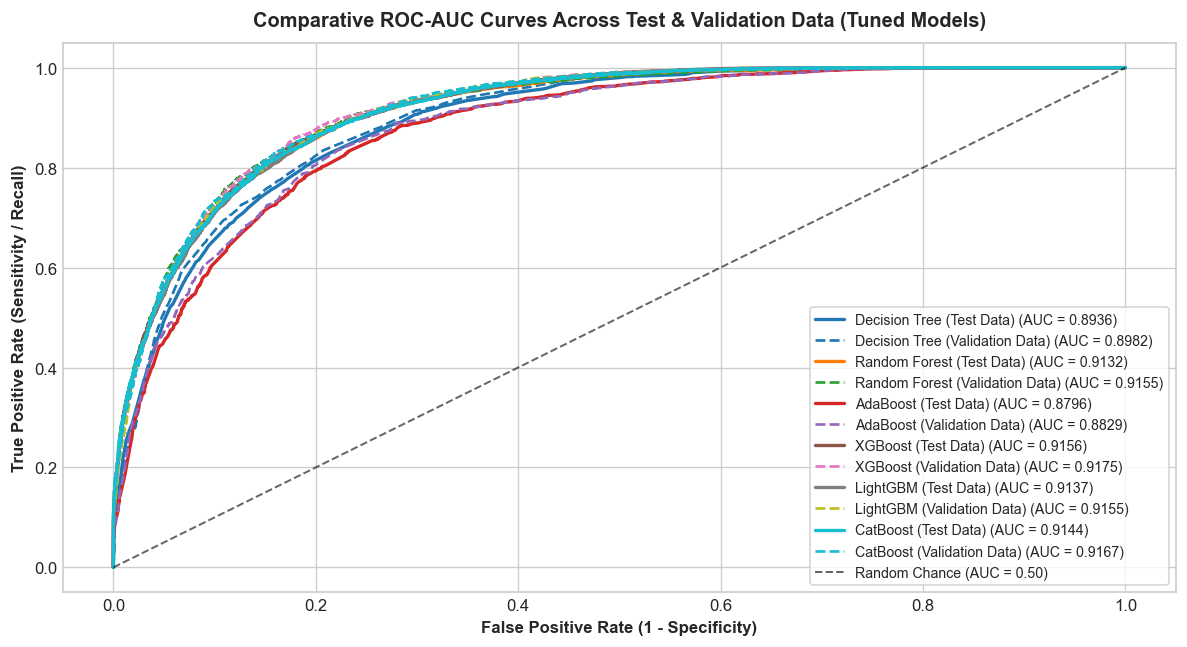


 📊 CONFUSION MATRICES: TUNED MODELS (6 Models)


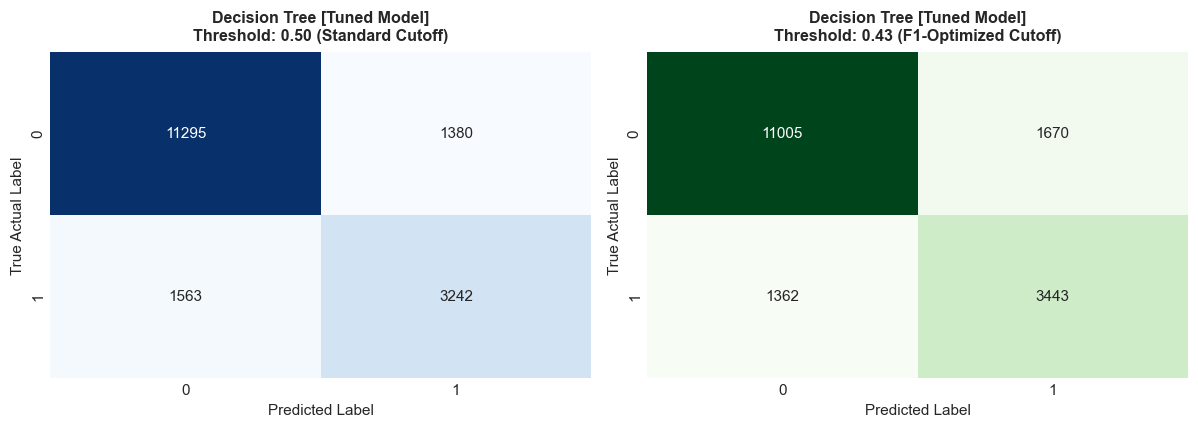

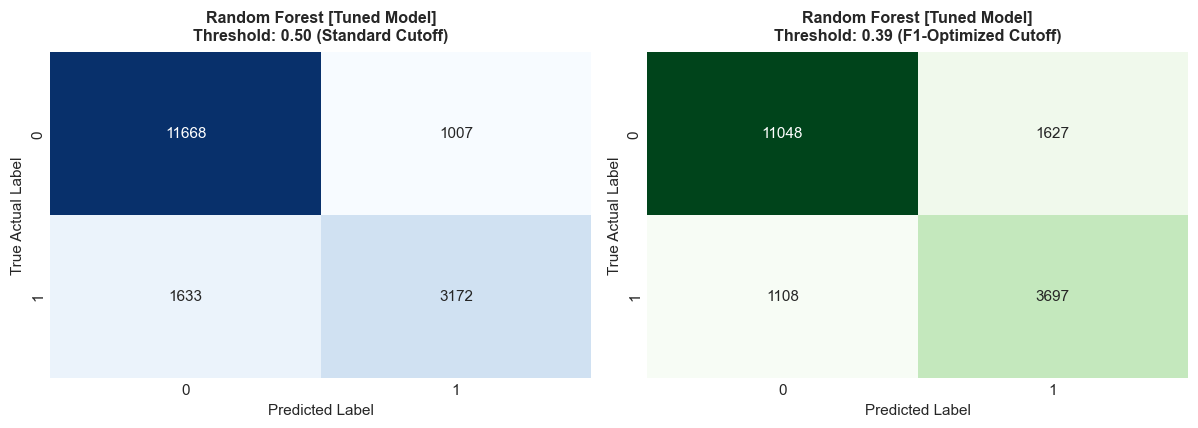

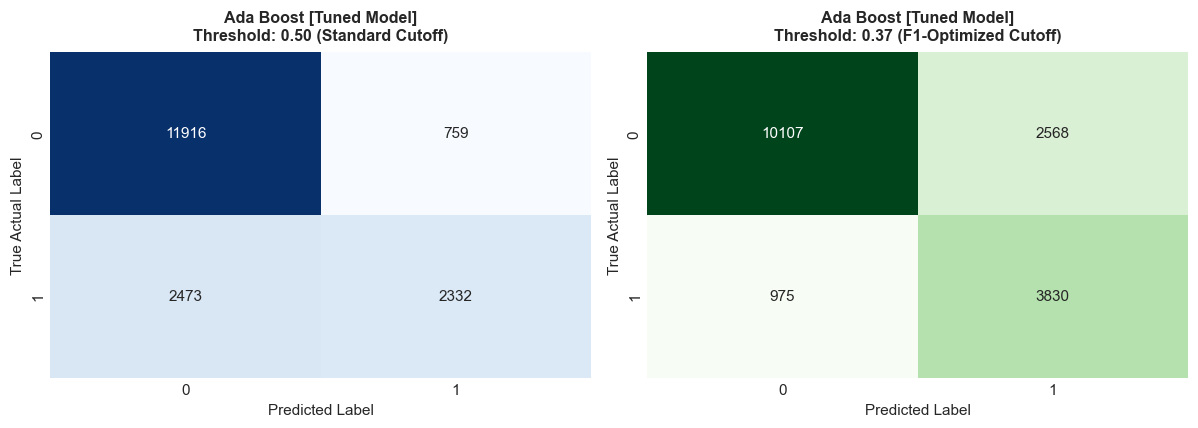

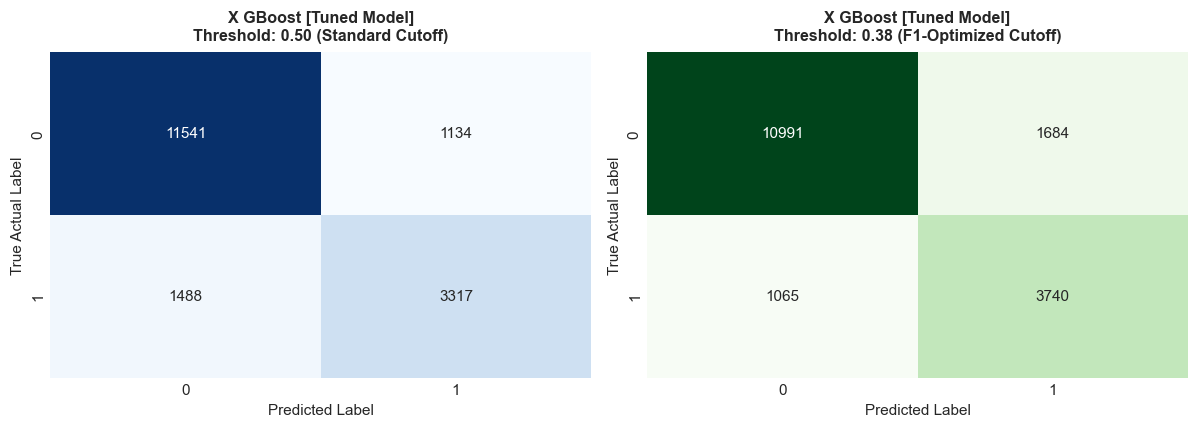

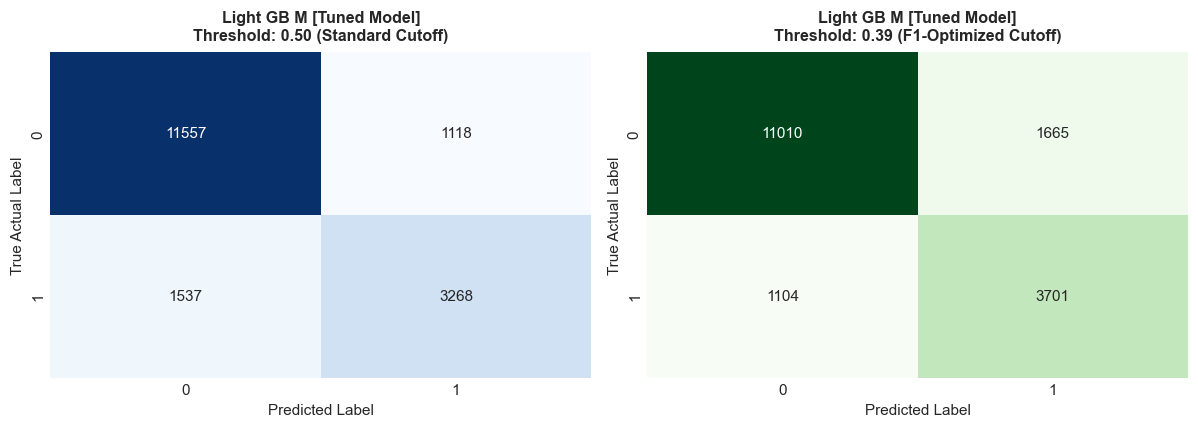

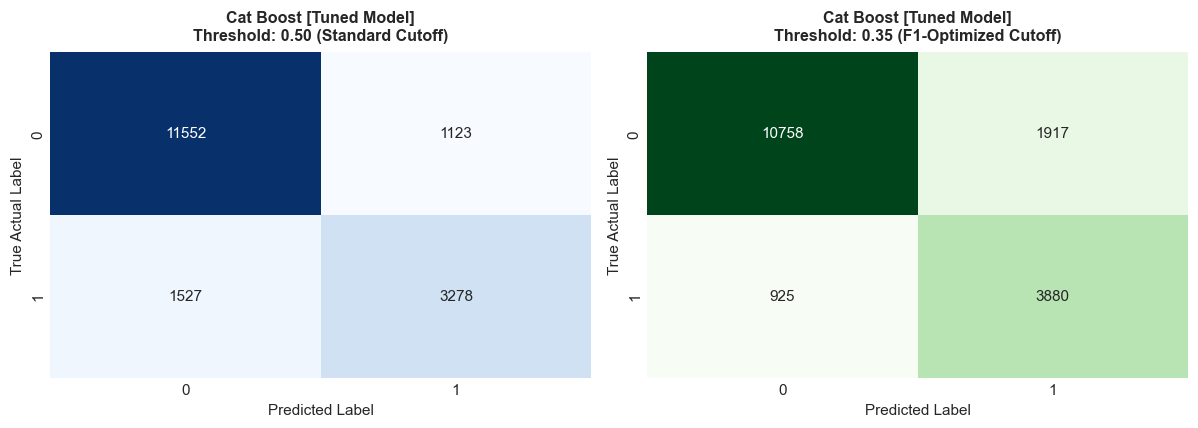


 🏆 ALL 28 FEATURE IMPORTANCES (TUNED MODELS: 6 Model(s))


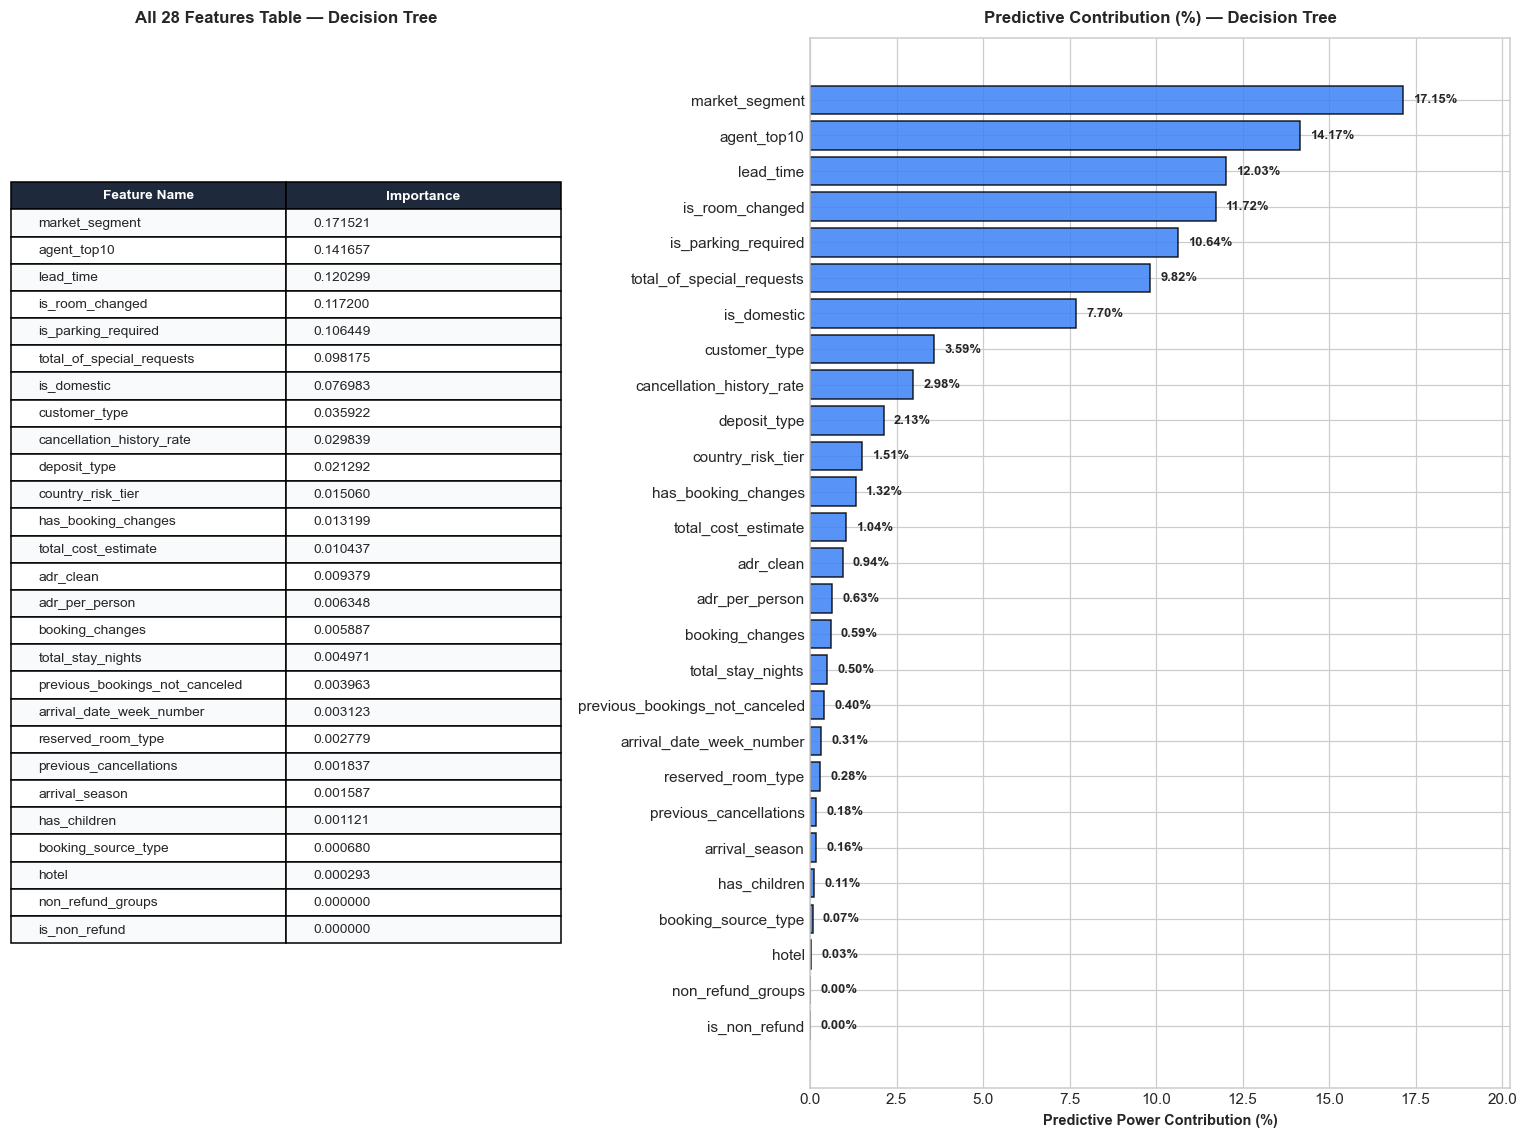

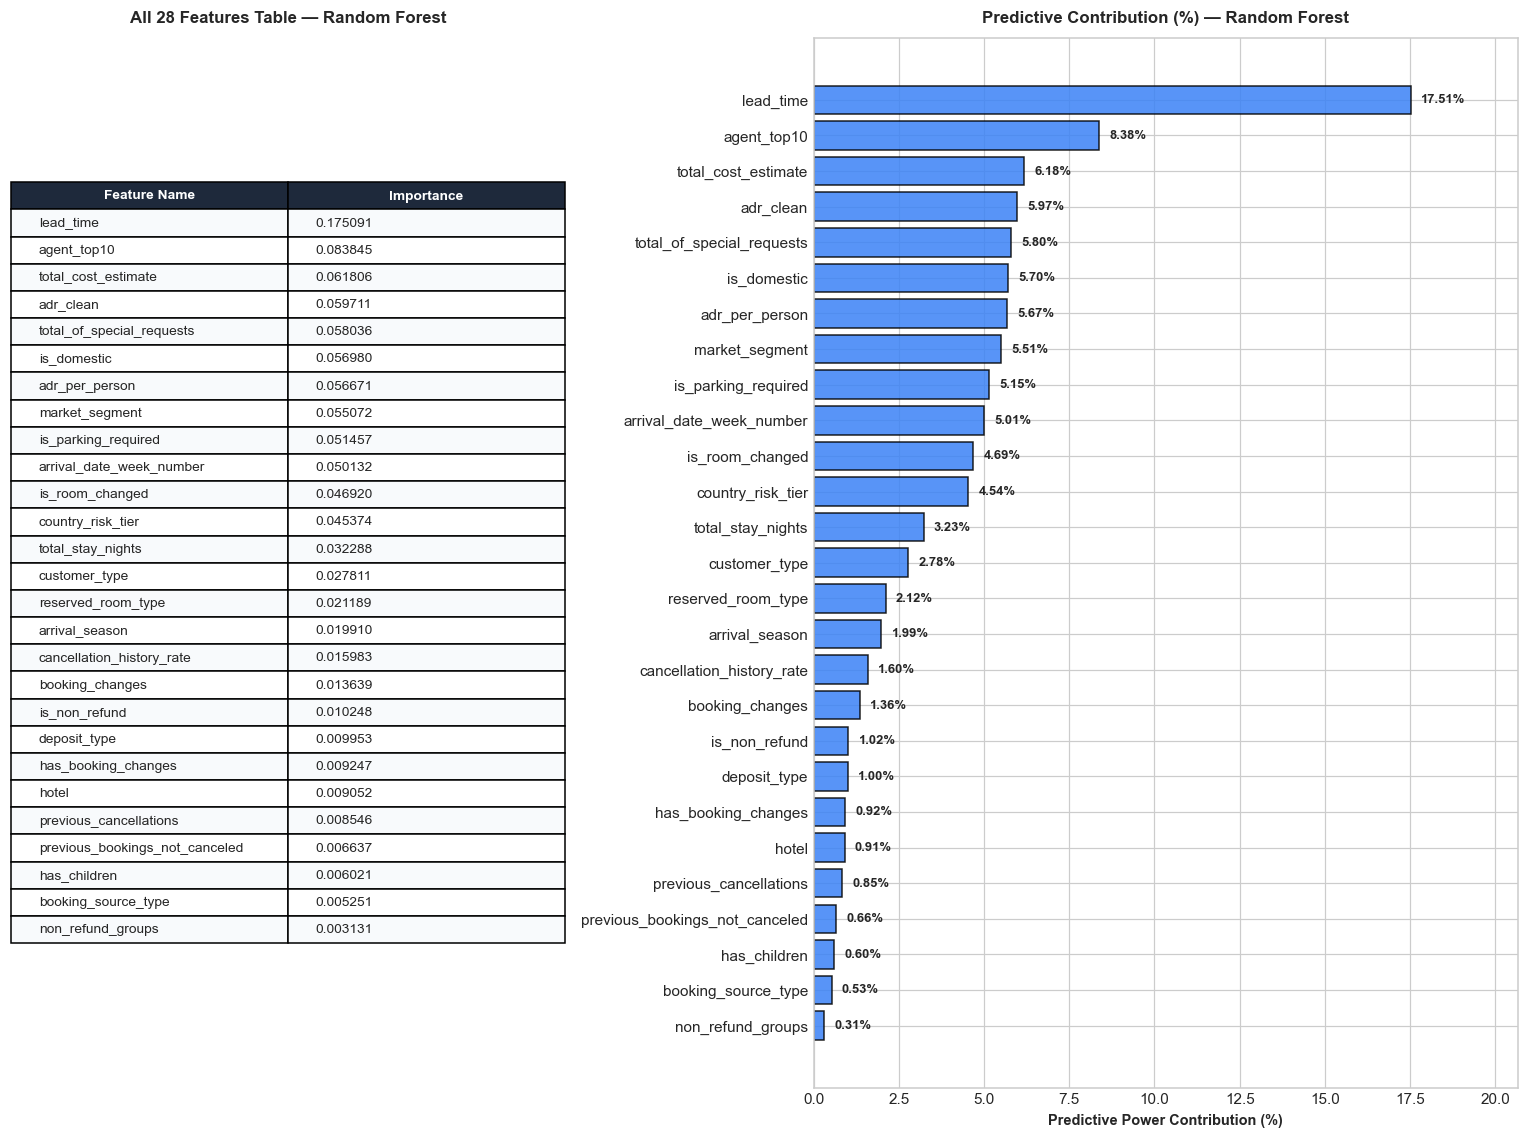

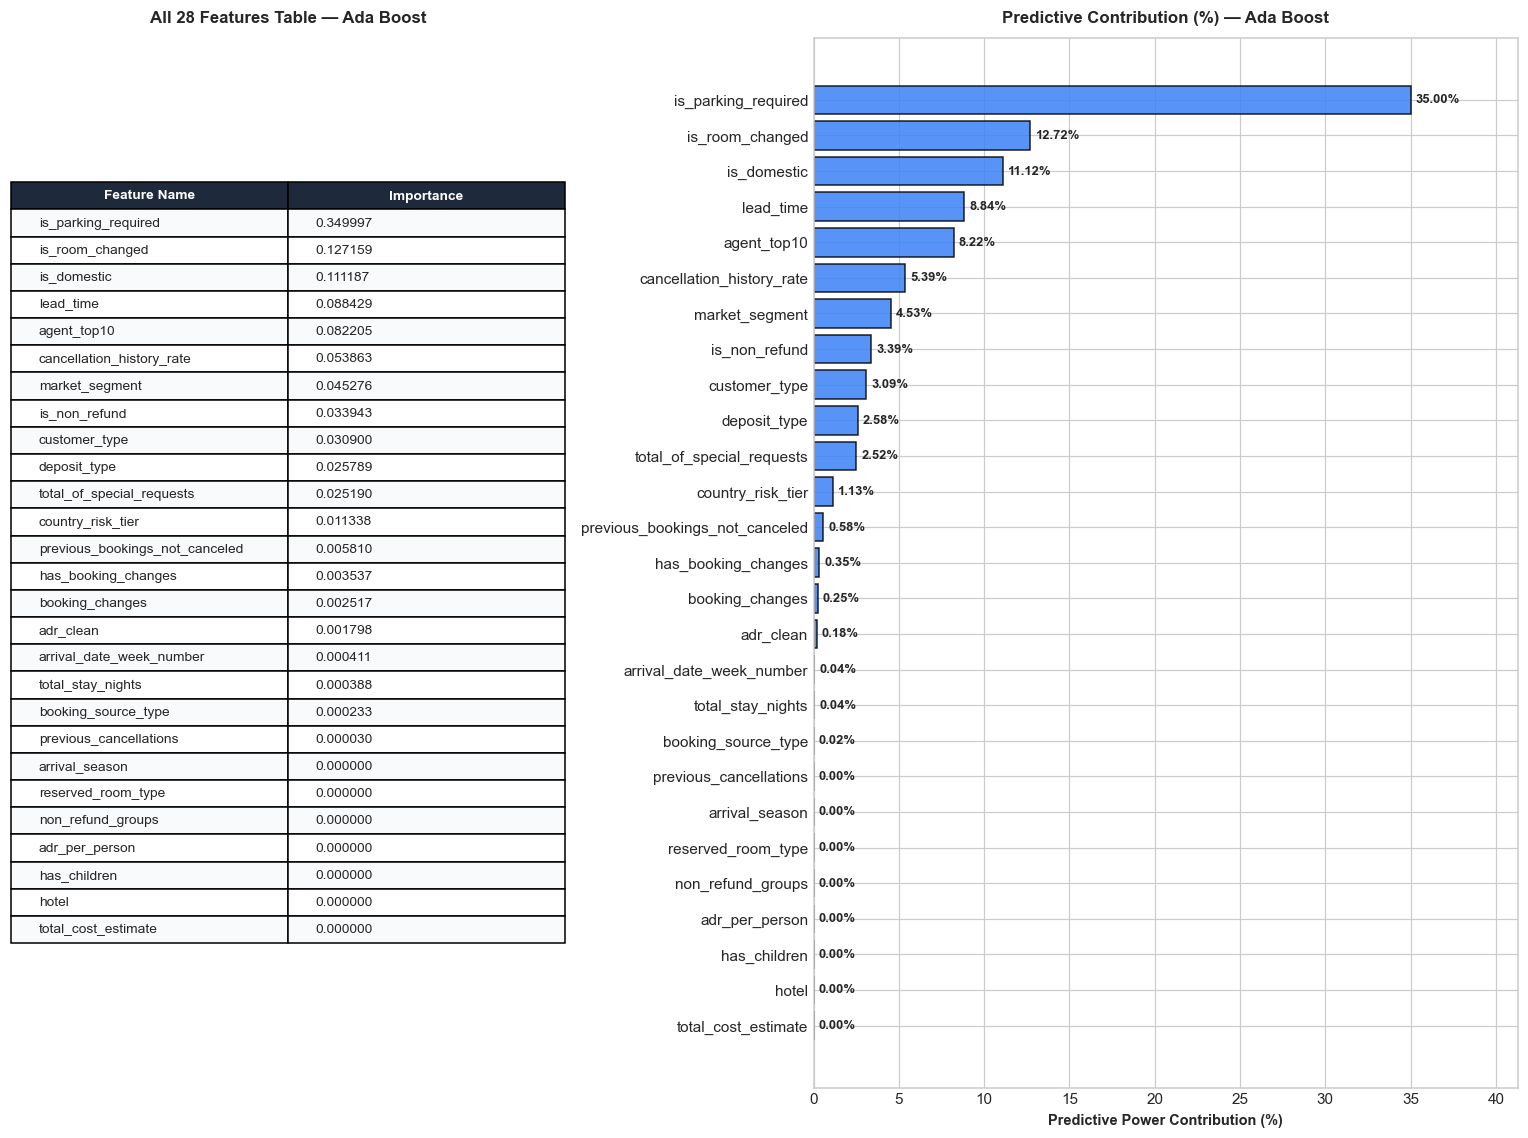

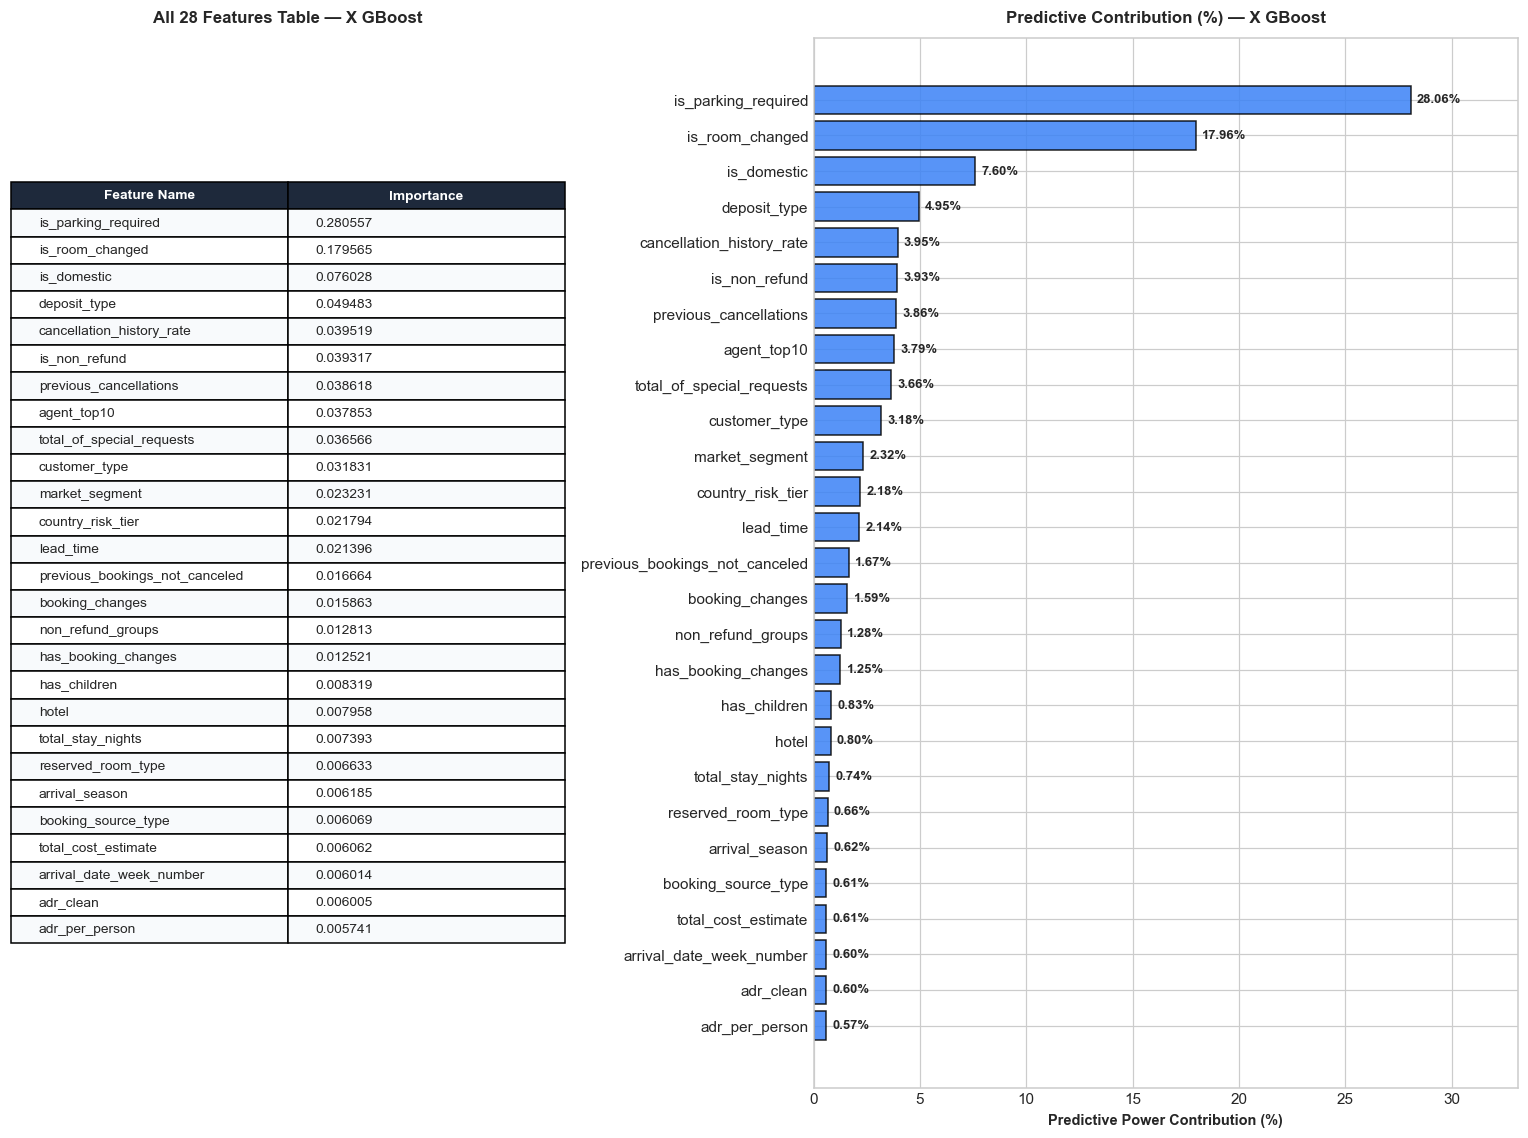

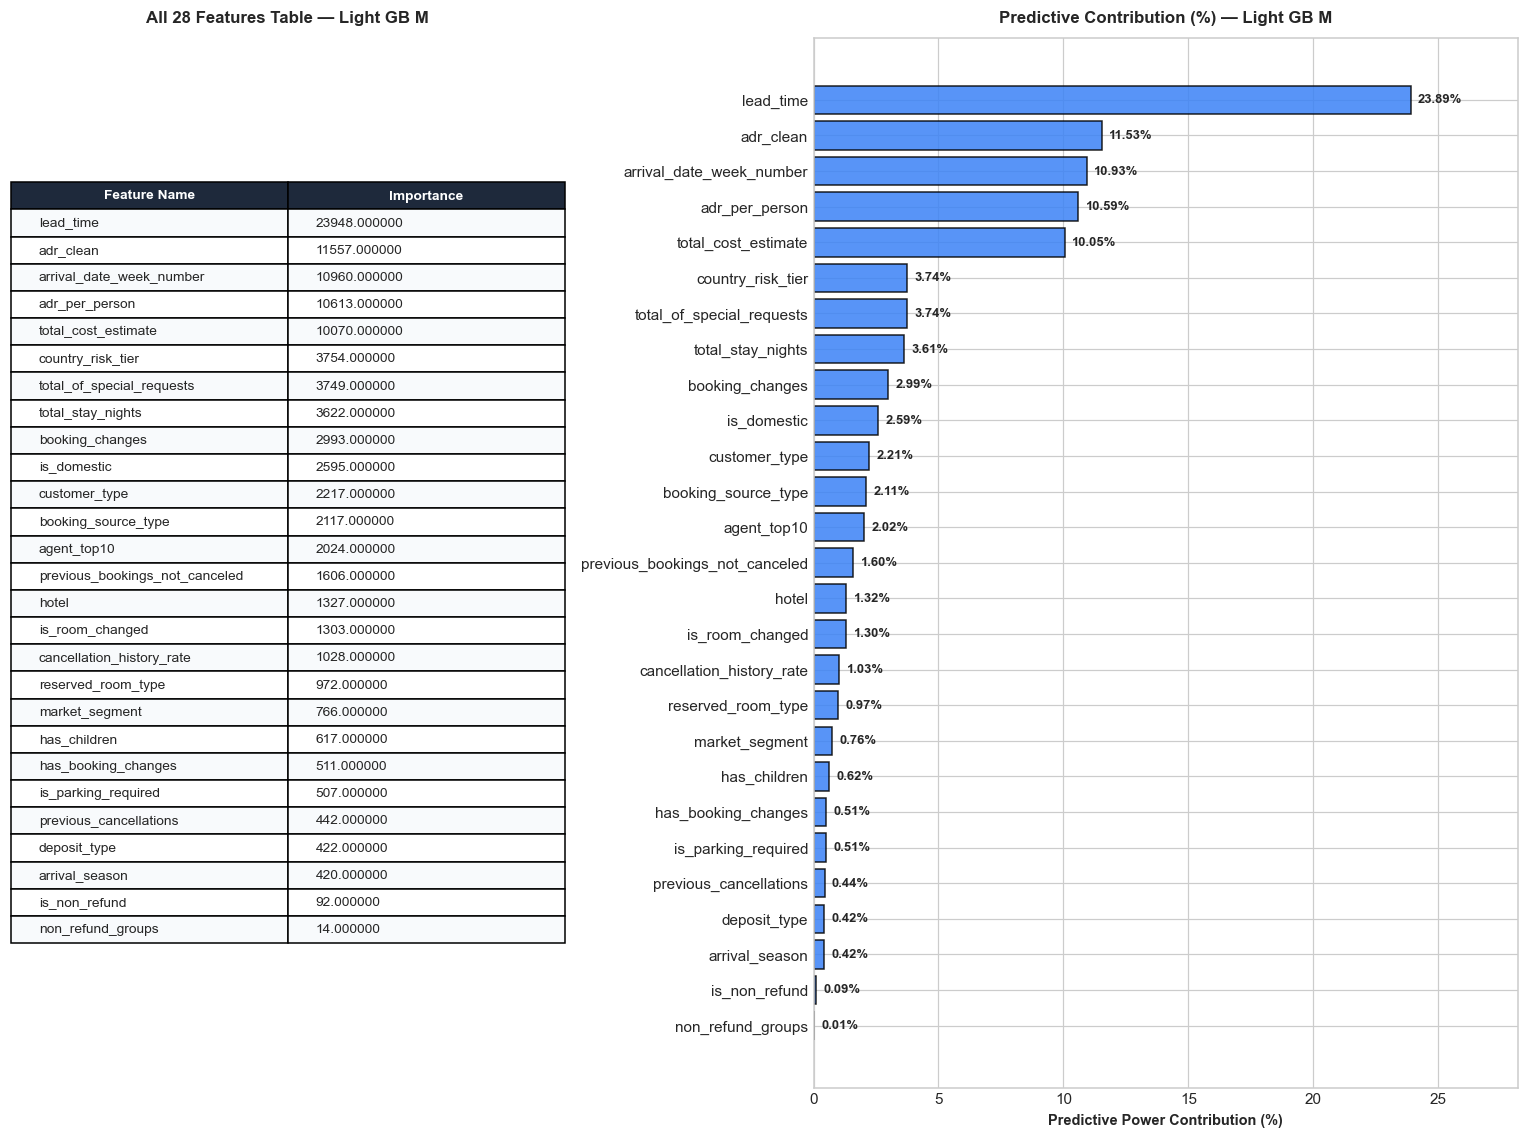

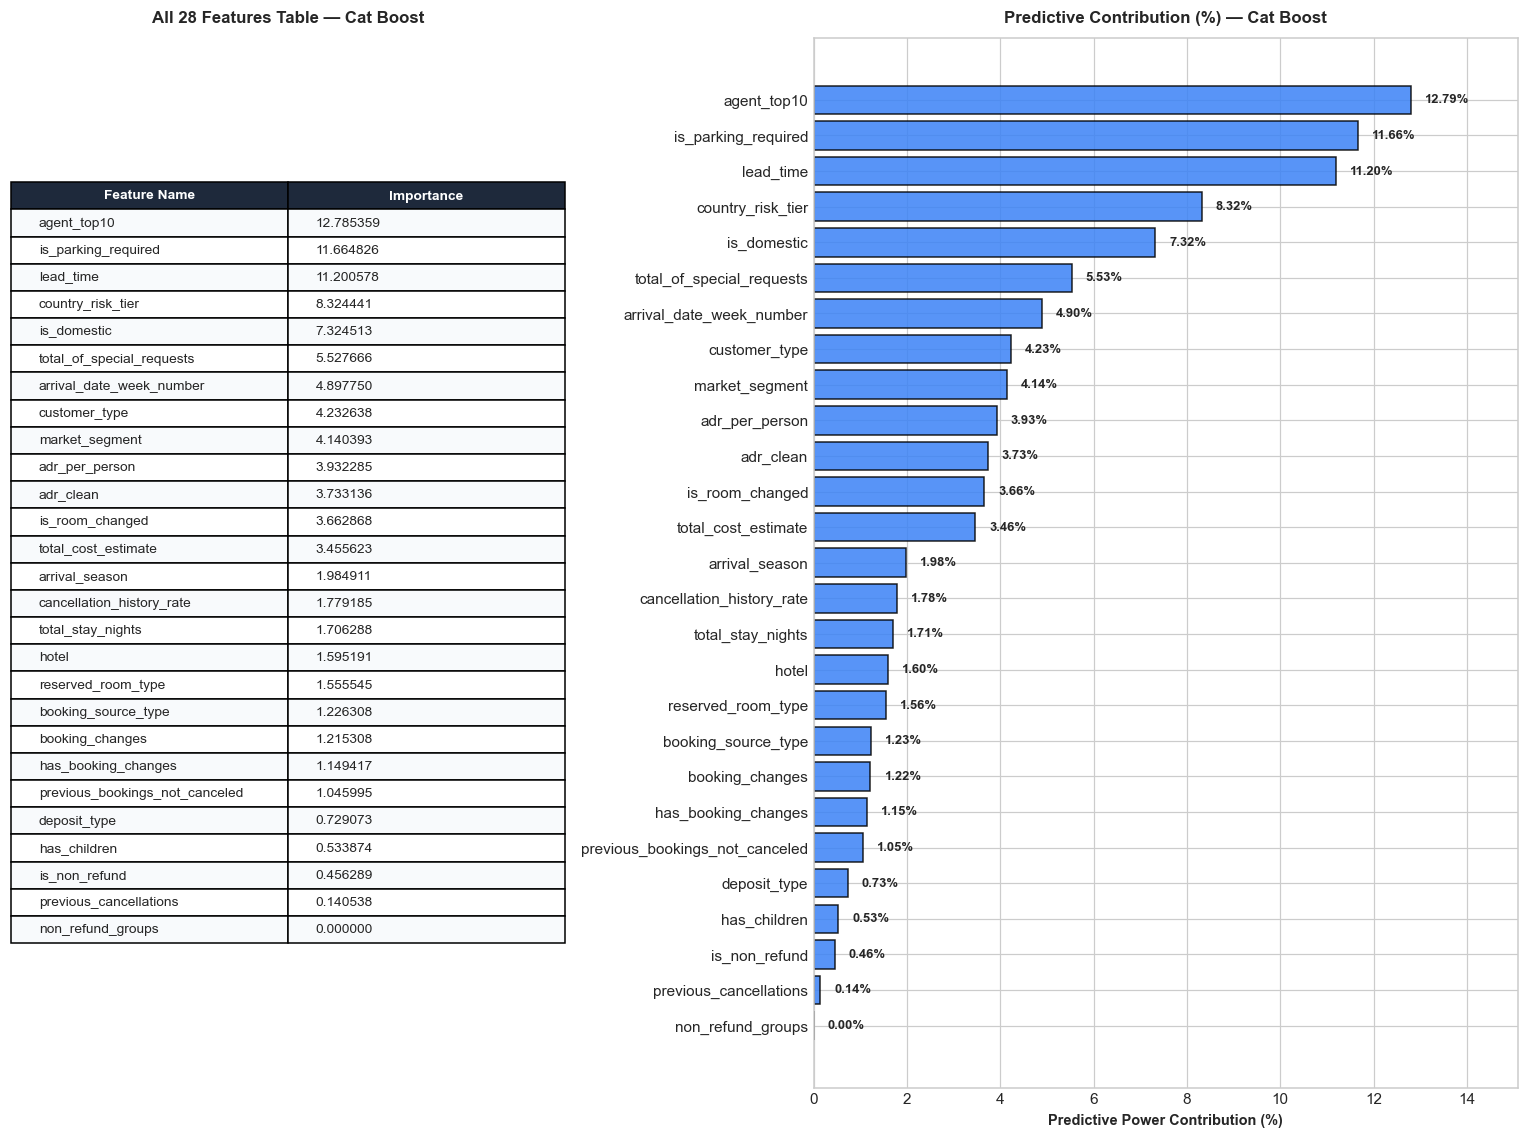

In [18]:
# ==============================================================================
# 8. VISUAL DIAGNOSTIC DASHBOARD (ROC CURVE, CONFUSION MATRIX, FEATURE IMPORTANCE)
# ==============================================================================

# 🎯 FEATURE IMPORTANCE VISUALIZATION CONTROL (Change k to show more/fewer features):
TOP_K_FEATURES = 'max'  # Set to 'max' / 'all' for all features, or any number e.g. 15, 20

# ------------------------------------------------------------------------------
# 1. COMPARATIVE ROC-AUC CURVES (TUNED MODELS: TEST DATA VS VALIDATION DATA)
# ------------------------------------------------------------------------------
# Filter model probabilities strictly to tuned models
tuned_models_keys = [k for k in model_probabilities_test.keys() if "(Tuned)" in k or "(tuned)" in k.lower()]

if len(tuned_models_keys) > 0:
    print("=" * 85)
    print(f" 📈 COMPARATIVE ROC-AUC CURVES: TUNED MODELS ({len(tuned_models_keys)} Model(s))")
    print("=" * 85)
    plt.figure(figsize=(10, 5.5), dpi=120)
    
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(tuned_models_keys) * 2, 10)))
    color_idx = 0
    
    for name in tuned_models_keys:
        base_name = name.replace(" (Tuned)", "").replace(" (Baseline)", "").strip()
        
        # 1. Test Data Curve (Solid Line)
        t_probs = model_probabilities_test[name]
        fpr_t, tpr_t, _ = roc_curve(y_test, t_probs)
        auc_t = roc_auc_score(y_test, t_probs)
        plt.plot(fpr_t, tpr_t, label=f"{base_name} (Test Data) (AUC = {auc_t:.4f})", color=colors[color_idx], lw=2.0)
        color_idx += 1
        
        # 2. Validation Data Curve (Dashed Line)
        if name in model_probabilities_val:
            v_probs = model_probabilities_val[name]
            fpr_v, tpr_v, _ = roc_curve(y_val, v_probs)
            auc_v = roc_auc_score(y_val, v_probs)
            plt.plot(fpr_v, tpr_v, label=f"{base_name} (Validation Data) (AUC = {auc_v:.4f})", color=colors[color_idx], lw=1.6, linestyle='--')
            color_idx += 1

    plt.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Random Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
    plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontweight='bold')
    plt.title('Comparative ROC-AUC Curves Across Test & Validation Data (Tuned Models)', fontweight='bold', pad=10)
    plt.legend(loc='lower right', frameon=True, fontsize=8.5)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 2. CONFUSION MATRICES (SINGLE PAIR PER BEST TUNED MODEL VARIANT)
# ------------------------------------------------------------------------------
def get_canonical_family_key(name):
    clean = re.sub(r'[\s_\-\.]+', '', str(name).lower())
    clean = clean.replace('(tuned)', '').replace('(baseline)', '').replace('classifier', '').strip()
    try: return resolve_model_name(clean)
    except Exception: return clean

best_variant_per_family = {}
for m_key in model_predictions_tuned.keys():
    fam_key = get_canonical_family_key(m_key)
    if "(Tuned)" in m_key or "(tuned)" in m_key.lower():
        best_variant_per_family[fam_key] = m_key

target_models_for_viz = list(best_variant_per_family.values())

if len(target_models_for_viz) > 0:
    print("\n" + "=" * 85)
    print(f" 📊 CONFUSION MATRICES: TUNED MODELS ({len(target_models_for_viz)} Models)")
    print("=" * 85)
    
    for model_name in target_models_for_viz:
        opt_preds = model_predictions_tuned[model_name]
        std_preds = model_predictions_default.get(model_name, opt_preds)
        opt_th = best_thresholds_dict.get(model_name, 0.50)
        
        base_name = model_name.replace(" (Tuned)", "").replace(" (Baseline)", "").replace("Classifier", "").strip()
        base_name = re.sub(r'(\w)([A-Z])', r'\1 \2', base_name)
        
        fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=110)
        
        # Left: Standard 0.50 Cutoff
        sns.heatmap(confusion_matrix(y_test, std_preds), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
        axes[0].set_title(f"{base_name} [Tuned Model]\nThreshold: 0.50 (Standard Cutoff)", fontweight='bold', fontsize=10.5, pad=8)
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Actual Label')
        
        # Right: Optimized Cutoff
        sns.heatmap(confusion_matrix(y_test, opt_preds), annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
        axes[1].set_title(f"{base_name} [Tuned Model]\nThreshold: {opt_th:.2f} (F1-Optimized Cutoff)", fontweight='bold', fontsize=10.5, pad=8)
        axes[1].set_xlabel('Predicted Label')
        axes[1].set_ylabel('True Actual Label')
        
        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------------------------
# 3. TOP K FEATURE IMPORTANCES (SIDE-BY-SIDE: TABLE ON LEFT, BAR CHART ON RIGHT)
# ------------------------------------------------------------------------------
models_with_importance = {}
for m_name in target_models_for_viz:
    if m_name in fitted_models:
        m_obj = fitted_models[m_name]
        if hasattr(m_obj, "feature_importances_"):
            models_with_importance[m_name] = (m_obj.feature_importances_, X_train.columns)
        elif hasattr(m_obj, "named_steps") and hasattr(m_obj.named_steps.get('classifier', None), "feature_importances_"):
            clf = m_obj.named_steps['classifier']
            prep = m_obj.named_steps.get('preprocessor', None)
            feat_names = prep.get_feature_names_out() if prep else X_train.columns
            models_with_importance[m_name] = (clf.feature_importances_, feat_names)

if len(models_with_importance) > 0:
    total_active_feats = len(X_train.columns)
    if 'TOP_K_FEATURES' in globals() and TOP_K_FEATURES is not None:
        if str(TOP_K_FEATURES).strip().lower() in ['max', 'all', '-1']:
            k_val = total_active_feats
            title_prefix = f"ALL {total_active_feats}"
        else:
            try:
                k_val = min(int(TOP_K_FEATURES), total_active_feats)
                title_prefix = f"TOP {k_val}" if k_val < total_active_feats else f"ALL {total_active_feats}"
            except Exception:
                k_val = 15
                title_prefix = "TOP 15"
    else:
        k_val = 15
        title_prefix = "TOP 15"
    print("\n" + "=" * 85)
    print(f" 🏆 {title_prefix} FEATURE IMPORTANCES (TUNED MODELS: {len(models_with_importance)} Model(s))")
    print("=" * 85)
    
    for m_name, (raw_imp, f_names) in models_with_importance.items():
        clean_names = [f.replace('cat__', '').replace('num__', '') for f in f_names]
        grouped_dict = {}
        for fn, imp_val in zip(clean_names, raw_imp):
            for orig_c in X_train.columns:
                if fn.startswith(orig_c):
                    fn = orig_c
                    break
            grouped_dict[fn] = grouped_dict.get(fn, 0) + imp_val
            
        imp_df = pd.DataFrame(list(grouped_dict.items()), columns=['Feature Name', 'Importance'])
        imp_df['Contribution (%)'] = (imp_df['Importance'] / imp_df['Importance'].sum() * 100).round(2)
        imp_df = imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
        
        display_m_name = m_name.replace(" (Tuned)", "").replace(" (Baseline)", "").replace("Classifier", "").strip()
        display_m_name = re.sub(r'(\w)([A-Z])', r'\1 \2', display_m_name)
        
        # Select top k features
        top_k = imp_df.head(k_val).copy()
        
        # Dynamic height based on k
        fig_height = max(5.0, 0.35 * len(top_k) + 1.0)
        fig, (ax_tbl, ax_bar) = plt.subplots(
            1, 2, 
            figsize=(14, fig_height), 
            dpi=110, 
            gridspec_kw={'width_ratios': [1.1, 1.4]}
        )
        
        ax_tbl.axis('off')
        table_data = [[row['Feature Name'], f"{row['Importance']:.6f}"] for _, row in top_k.iterrows()]
        tbl = ax_tbl.table(
            cellText=table_data,
            colLabels=['Feature Name', 'Importance'],
            loc='center',
            cellLoc='left',
            colColours=['#1E293B', '#1E293B']
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1.0, 1.25)
        
        for (row_idx, col_idx), cell in tbl.get_celld().items():
            if row_idx == 0:
                cell.get_text().set_color('white')
                cell.get_text().set_weight('bold')
            elif row_idx % 2 == 1:
                cell.set_facecolor('#F8FAFC')
                
        ax_tbl.set_title(f"{title_prefix.title()} Features Table — {display_m_name}", fontweight='bold', fontsize=11, pad=10)
        
        bar_data = top_k.iloc[::-1]
        bars = ax_bar.barh(bar_data['Feature Name'], bar_data['Contribution (%)'], color='#3B82F6', edgecolor='black', alpha=0.85)
        ax_bar.set_title(f"Predictive Contribution (%) — {display_m_name}", fontweight='bold', fontsize=11, pad=10)
        ax_bar.set_xlabel('Predictive Power Contribution (%)', fontweight='bold', fontsize=9.5)
        ax_bar.set_xlim(0, max(top_k['Contribution (%)']) * 1.18)
        
        for idx, val in enumerate(bar_data['Contribution (%)']):
            ax_bar.text(val + 0.3, idx, f"{val:.2f}%", va='center', fontsize=8.5, fontweight='bold')
            
        plt.tight_layout()
        plt.show()



## 9. Interactive Real-Time Prediction Simulator
### ✍️ **Developer Guide: How to Test Live Guest Bookings**
> **To test a new hypothetical booking**: Pass any sample row or dictionary into the simulator below to view the real-time **cancellation risk probability percentage** and **business action recommendation**.

```python
# --- Example: Simulating a Custom High-Risk Guest Booking ---
custom_guest = X_test.iloc[[0]].copy()
custom_guest['lead_time'] = 350                  # Booked almost a year in advance
custom_guest['requires_parking'] = 0             # No parking space requested
custom_guest['has_booking_changes'] = 0          # No changes made
```



In [19]:
# ==============================================================================
# 10. REAL-TIME BOOKING CANCELLATION PREDICTOR SIMULATOR
# ==============================================================================
# Sample guest booking data
sample_guest_booking = X_test.iloc[[0]].copy()

# Pick the best evaluated model
active_model_name = list(model_predictions_tuned.keys())[-1]
active_model = fitted_models[active_model_name]
opt_thresh = best_thresholds_dict.get(active_model_name, 0.50)

# Compute probability
if hasattr(active_model, "predict_proba"):
    guest_cancel_prob = active_model.predict_proba(sample_guest_booking)[0, 1]
else:
    from scipy.special import expit
    guest_cancel_prob = expit(active_model.decision_function(sample_guest_booking))[0]

is_cancel_pred = int(guest_cancel_prob >= opt_thresh)
status_label = "🚨 HIGH RISK: LIKELY TO CANCEL" if is_cancel_pred == 1 else "✅ LOW RISK: LIKELY TO SHOW UP"

print("=" * 80)
print(f" 🏨 REAL-TIME BOOKING CANCELLATION RISK ASSESSMENT ({active_model_name})")
print("=" * 80)
print(f" Predicted Cancellation Risk : {guest_cancel_prob * 100:.1f}%")
print(f" Optimal Decision Threshold  : {opt_thresh * 100:.1f}%")
print(f" Final System Classification : {status_label}")
print("=" * 80)


 🏨 REAL-TIME BOOKING CANCELLATION RISK ASSESSMENT (CatBoost (Tuned))
 Predicted Cancellation Risk : 18.3%
 Optimal Decision Threshold  : 35.1%
 Final System Classification : ✅ LOW RISK: LIKELY TO SHOW UP
